In [1]:
import pandas as pd 
import pandas_ta as ta
import datetime 
import warnings as ws
ws.simplefilter('ignore')
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import pyfolio as pf
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import pickle as pk
import  quantstats as qs
from sklearn.metrics import f1_score  , accuracy_score ,  roc_auc_score , precision_score , matthews_corrcoef , r2_score
import matplotlib.cm as cm
import random
import os
import json
from tqdm import tqdm
from bayes_opt import BayesianOptimization
from bayes_opt import acquisition
import itertools
from sklearn.model_selection import KFold , ParameterGrid , TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from kneed import KneeLocator
from sklearn.preprocessing import StandardScaler
from joblib import Parallel, delayed
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin, clone ,TransformerMixin
from arch.bootstrap import MovingBlockBootstrap
from hurst import compute_Hc
from scipy.stats import skew , kurtosis , rankdata
import shap
import copy
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.cluster import SpectralClustering
from scipy.stats import norm
from sklearn.utils import shuffle ,resample

In [2]:

tickers =   ['AUDUSD']

dataset = {}
common_index = None
for symbol in tickers:
    # Read the CSV file for the symbol
    dt = pd.read_csv(f'{symbol}', index_col=0)
    dt.index = pd.DatetimeIndex(dt.index)
    dt.index = dt.index.tz_localize('UTC')
#     sample period for walforward testing
    dt =dt.loc['2012':'2025']
    if common_index is None:
        common_index = dt.index
    else:
        common_index = common_index.intersection(dt.index)

    
    dataset[symbol] = dt

        

sample = {}
dt = None
# daily data
for ticker in tickers:
    data = dataset[ticker]
    sample[ticker] = data.loc[common_index]


In [3]:
def make_directory(strategy_name):
    directory = 'FOREX_ML'
    if not os.path.exists(directory):
        os.makedirs(directory)

    # creating subdirectory for strategy
    subdirectory_path =   os.path.join(directory , strategy_name)

    if not os.path.exists(subdirectory_path):
        os.makedirs(subdirectory_path)



# indicator function
def HedgeRatio(y , x , window):
    hr = np.full_like(y.values , np.nan)

    x  = x.values.reshape(-1 , 1)
    y  = y.values.reshape(-1 , 1)

    for i in range(window , y.shape[0]):
        X_ , Y_ = x[i-window:i] , y[i-window:i]
        m = LinearRegression().fit(X_,  Y_)
        hr[i] = m.coef_[0][0]
    return hr


def calculate_MOM_Burst( dt ,  lookback  ):
#    calculating the indicator mom burst 
    candle_range = dt['high']-dt['low']
    mean_range = candle_range.rolling(window  = lookback).mean()
    std_range =  candle_range.rolling(window = lookback).std()
    mom_burst = (candle_range-mean_range)/std_range

    return mom_burst  , mean_range


def TrendIntensityIndex(dt , window):
    ma = dt.rolling(window=window).mean()
    day_above_average = (dt>ma).rolling(window = window).sum()
    return 100* day_above_average/window


def Z_score(dt ,length):
    mean  = dt.ewm(span =length).mean()
    std = dt.ewm(span = length).std()
    return (dt-mean)/std


def line_angle(df_, n):
    angle = np.full_like(df_, np.nan)  # Initialize with NaNs
    
    for i in range(n, len(df_)):
        dist = i - (i - n)
        if dist != 0:
            angle[i] = np.arctan((df_.iloc[i] - df_.iloc[i - n]) / dist) * 180 / np.pi

    return pd.Series(angle, index=df_.index)


def kaufMan_EF_Ratio(dt , n):
    absolute_change = abs(dt  - dt .shift(n))
    total_change = dt.diff().abs().rolling(window=n).sum()
    return absolute_change / total_change


def ComputeRegime_HURST(dt , window):
    rolling_hurst_exponents = dt.rolling(window = window).apply(lambda X: compute_Hc(X)[0] , raw =False)
    regime = pd.Series(rolling_hurst_exponents , rolling_hurst_exponents.index  , name = 'HurstRegime')
    return regime


class WalkForwardSplit():
    def __init__(self):
        self.training_days = None
        self.testing_days = None
        
    def split(self , InputSet:pd.DataFrame , anchored = False):
        InputSpace_Range = len(InputSet)
        
        for Start in range(0 , InputSpace_Range  - self.testing_days  + 1, self.testing_days):

            Start_test = Start + self.training_days
            End_test =   min(Start_test + self.testing_days , InputSpace_Range)

            Train = np.arange(0 if anchored else Start , Start_test)
            Test =  np.arange(Start_test , End_test)
            
            yield Train  ,  Test
    
            if  InputSpace_Range==End_test :
                break

                                
class Purged_KFold_cv:
    
    def __init__(self , n_splits = 10 , purge_window = 100 , embargo_window = 100):
        self.n_splits = n_splits
        self.kf = KFold(n_splits=n_splits, shuffle=False)
        self.purge_window = purge_window
        self.embargo_window = embargo_window
        
    def PurgingEmbargo(self,train_idx , test_idx):
        train_start = self.samples.iloc[train_idx].index[0]
        train_end   = self.samples.iloc[train_idx].index[-1]
        train = self.samples.iloc[train_idx]
        test = self.samples.iloc[test_idx]

#       purging and embargo
        end_embargo = train_start + pd.Timedelta(days = self.embargo_window)
        df_0 = train.loc[train_start:end_embargo].index
        start_purging  = train_end - pd.Timedelta(days = self.purge_window)    
        
#       removing overlapping window among train and test 
        df_1 = train.loc[start_purging:train_end].index
        banned_idx = df_0.union(df_1)
        Overlapping_idx = [i for i in banned_idx if i in test.index]
        train = train.drop(Overlapping_idx)

        return [self.samples.index.get_loc(i) for i in train.index]
    
    def split(self , X , purging = True):
#       setting sample for validation
        self.samples = X
        
        for train_index, test_index in self.kf.split(self.samples):
            if purging:
                train_index = self.PurgingEmbargo(train_index ,test_index)
            
            yield train_index , test_index
            
    @property
    def get_n_splits(self):
        return self.n_splits
    
    
    @property
    def get_ndim(self):
        return (self.samples.shape[0] , self.n_splits)
    

class CPCV_Generator:
    def __init__(self, n_splits:int = 10 , n_samples = 2 , purge_window:int = 100 , embargo_window:int =100):
        self.n = n_splits
        self.k = n_samples
        self.purge_window = purge_window
        self.embargo_window = embargo_window
        
        

    def cpcv_generator(self, t_span, n, k):
        # t_span = total samples, n = n_splits, k = number of samples to select at a time

        group_num = np.arange(t_span) // (t_span // n)
        group_num[group_num == n] = n-1

        test_groups = np.array(list(itertools.combinations(np.arange(n), k))).reshape(-1, k)
        C_nk = len(test_groups)
        n_paths = C_nk * k // n

        is_test_group = np.full((n, C_nk), fill_value=False)
        self.is_test = np.full((t_span, C_nk), fill_value=False)

        for k_idx, sample_group in enumerate(test_groups):
            is_test_group[sample_group, k_idx] = True

            # Assigning the test folds for all groups in the sample group
            mask = np.isin(group_num, sample_group)
            self.is_test[mask, k_idx] = True

        path_folds = np.full((n, n_paths), fill_value=np.nan)

        for i in range(n_paths):
            for j in range(n):
                s_idx = is_test_group[j, :].argmax().astype(int)
                path_folds[j, i] = s_idx
                is_test_group[j, s_idx] = False

        paths = np.full((t_span, n_paths), fill_value=np.nan)

        for p in range(n_paths):
            for i in range(n):
                mask = (group_num == i)
                paths[mask, p] = int(path_folds[i, p])

        return C_nk , paths


    def PurgingEmbargo(self,train_idx , test_idx):
        train_start = self.samples.iloc[train_idx].index[0]
        train_end   = self.samples.iloc[train_idx].index[-1]
        train = self.samples.iloc[train_idx]
        test = self.samples.iloc[test_idx]

#       purging and embargo
        end_embargo = train_start + pd.Timedelta(days = self.embargo_window)
        df_0 = train.loc[train_start:end_embargo].index
        start_purging  = train_end - pd.Timedelta(days = self.purge_window)    
        
#       removing overlapping window among train and test 
        df_1 = train.loc[start_purging:train_end].index
        banned_idx = df_0.union(df_1)
        Overlapping_idx = [i for i in banned_idx if i in test.index]
        train = train.drop(Overlapping_idx)

        return [self.samples.index.get_loc(i) for i in train.index]
    
        
    def split(self , X):
        self.samples = X
        self.num_sim  , self.paths = self.cpcv_generator(X.shape[0] , self.n , self.k)
        self.train_len , self.test_len = 0 , 0
   
        for sim in range(self.is_test.shape[1]):
            train_idx , test_idx = np.where(~self.is_test[:, sim])[0] , np.where(self.is_test[:, sim])[0]
            train_idx = self.PurgingEmbargo(train_idx , test_idx) 

            self.train_len+=len(train_idx)
            self.test_len+=len(test_idx)
            
            yield train_idx, test_idx
    
    
    @property
    def get_n_splits(self):
        return self.num_sim
    
    
    @property
    def get_ndim(self):
        return (self.samples.shape[0] , self.num_sim)
    
    
    @property
    def GetPath(self):
        return self.paths
        

    def GetTraningTestingWindow(self):
        return self.train_len//self.num_sim , self.test_len//self.num_sim


class BaggingBootstrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, estimator , n_estimators=5  , threshold = 0.5 , sample_weight = None , random_state = None):
        self.estimator = estimator
        self.threshold = threshold
        self.n_estimators = n_estimators
        self.sample_weight = sample_weight
        self.random_state = random_state
        self.fitted_models = []  
        self.strapper = None
        self.classes_ = None
        self.n_classes_ = None

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.n_classes_ = len(self.classes_)
        self.threshold_array = np.full(self.n_classes_ , self.threshold) 
        block_size = X.shape[0] // self.n_estimators 
        self.strapper = MovingBlockBootstrap(block_size, X, y, seed=self.random_state)
        self.fitted_models.clear()  

        for sample in self.strapper.bootstrap(self.n_estimators):
            X_train, y_train = sample[0][0], sample[0][1]
            clone_estimator = clone(self.estimator)
            sample_weight =  self.sample_weight[X_train.index] if self.sample_weight is not None else None 
            clone_estimator.fit(X_train, y_train , sample_weight = sample_weight)
            self.fitted_models.append(clone_estimator) 

        return self 

    def predict_proba(self, X):
        probabilities = np.array([model.predict_proba(X) for model in self.fitted_models])
        return np.mean(probabilities, axis=0)
   
    def predict(self, X):
        proba = self.predict_proba(X)

        above_threshold = proba >= self.threshold_array
        predicted_indices = np.where(
            above_threshold.any(axis=1),
            np.argmax(proba * above_threshold, axis=1),
            np.argmax(proba, axis=1)
        )

        return self.classes_[predicted_indices]


class NoiseEnhancer( BaseEstimator, TransformerMixin):
    def __init__(self , mu = 0.0 , sigma = 0.0 , skip_cols = [] , random_state = None):
        self.mu = mu
        self.sigma = sigma
        self.skip_cols = skip_cols
        self.random_state = random_state

    def fit(self , x , y = None):
        return self

    def fit_transform(self , X , y = None):
        X = X.copy()
        col = [c for c in X.columns if c not in self.skip_cols]
        np.random.seed(self.random_state)
        noise = np.random.normal(self.mu , self.sigma , X[col].shape) if self.sigma else 0
        X[col]+=noise
        return X
        
    
    def transform(self, X , y = None):
        return X
            

class VolatilityScaler(BaseEstimator, TransformerMixin):
    def __init__(self  , xi , c = 3.0  , col_name = '_VOL_RAW_REG_'  , skip_cols = [] , transformer = False):
        self.c = c
        self.transformer = transformer
        self.skip_cols = skip_cols
        self.col_name = col_name
        self.xi  = self.transformer(xi) if self.transformer else xi
        self.col = None
    
    def fit(self , x , y = None):
        self.col = [c for c in x.columns if c not in self.skip_cols + [self.col_name]]
        return self
    
    def transform(self  , X):
        X = X.copy()
        yi = self.transformer(X[self.col_name]) if self.transformer else X[self.col_name] 
        
        
        sigma = (yi/self.xi).clip(upper = self.c)
        X[self.col] = X[self.col].div(sigma, axis = 0)
        return X.drop(self.col_name , axis = 1)

In [4]:
class Analyzer:
    def __init__(self):
        self.objective_function = objective_function()
        self.params_grid = None

    
    def SetVar(self , dt , cmp_dt = None):
        self.objective_function.Intialize_Var(dt , cmp_dt)
        self.benchmark, self.DailyChange , self.hurst_category_yearly, self.kaufman_category_yearly , self.volatility = self.ComputeMetrics()

    
    def GetOptimalQuantile(self , iteration = 30):
        def target_function(x , y , mul):
            extreme_drops = []
            TRAIN_VAL_PERIODS = self.objective_function.TRAIN_VAL_PERIODS[-1]
            target_returns = self.DailyChange[:TRAIN_VAL_PERIODS].shift(-1).dropna()
            q_dn = round(x, 2)
            q_up = 1 - round(y, 2)
            mul =  round(mul, 2)
            
            # creating mask for outliers
            UP_Q =  target_returns.quantile(q_up)
            DN_Q =  target_returns.quantile(q_dn)
            UP_bound = UP_Q + mul * (UP_Q - DN_Q)
            DN_bound = DN_Q - mul * (UP_Q - DN_Q)
            extreme_drops.extend(target_returns[target_returns > UP_bound].index)
            extreme_drops.extend(target_returns[target_returns <  DN_bound].index)
            mask =  ~target_returns.index.isin(extreme_drops)
            return -round(abs(skew(target_returns[mask])) , 2)

        # setting up the optimizer
        self.optimizer =BayesianOptimization(
                        f=target_function,
                        pbounds=self.params_grid,
                        verbose=2,  # Verbose level (0, 1, or 2)
                        allow_duplicate_points = True , random_state = SEED)
        
#       running optimizer
        self.optimizer.maximize(init_points= 10 ,n_iter= iteration)
        x , y , mul = round(self.optimizer.max['params']['x'] , 2) , round(self.optimizer.max['params']['y'] , 2) , round(self.optimizer.max['params']['mul'] , 2)
        best_params = {'Quantiles': (x , 1 - y) , 'mul':mul}
        print('TargetVal:', self.optimizer.max['target'], 'Params:', best_params)
        return best_params


    
    def ComputeMetrics(self):
        dt = self.objective_function.data
        DailyChange = dt['close'].pct_change()
        benchmark =  ((1 + dt['close'].pct_change()).cumprod() - 1) * 100
        volatility = dt['close'].pct_change().ewm(span = 100).std() * 100
        
        hurst_exp = ComputeRegime_HURST(dt['close'] , window = 100)
        kf_ef = kaufMan_EF_Ratio(dt['close'] , 100)

        hurst_exp , kaufman_ef = {} , {}
        
        for year , group in dt.groupby(dt.index.year):
            hxp = ComputeRegime_HURST(group['close'] , window = 100).dropna()
            kf  = kaufMan_EF_Ratio(group['close'] , n = 100).dropna()
            hurst_exp[year]  = hxp.apply(lambda x: 'Trending' if 0.5 < x <= 1 else ('Mean-Reverting' if 0 < x < 0.5 else 'Random')).value_counts()
            kaufman_ef[year] = kf.apply(lambda x: 'High Efficiency' if x > 0.5 else ('Low Efficiency' if x < 0.2 else 'Medium Efficiency')).value_counts()
        
        return benchmark , DailyChange.dropna()*100 , pd.DataFrame(hurst_exp).fillna(0).T , pd.DataFrame(kaufman_ef).fillna(0).T , volatility


    def Plot(self):
    
        # Set up the figure and GridSpec
        fig = plt.figure(figsize=(14, 18))
        gs = GridSpec(6, 1, figure=fig, height_ratios=[3, 1, 1, 1, 1, 1])
    
        # Create subplots
        ax0 = fig.add_subplot(gs[0])  # Benchmark
        ax1 = fig.add_subplot(gs[1])  # DailyChange
        ax2 = fig.add_subplot(gs[2])  # Normal Distribution of DailyChange
        ax3 = fig.add_subplot(gs[3])  # Volatility
        ax4 = fig.add_subplot(gs[4])  # Hurst Exponent Category as bar chart
        ax5 = fig.add_subplot(gs[5])  # Kaufman Efficiency Ratio Category bar chart
    
        # Plot Benchmark (Equity Curve)
        ax0.plot(self.benchmark, color="blue", label="Benchmark", linewidth=2)
        ax0.set_ylabel("Cumulative Return (%)")
        ax0.set_title("Equity Curve - Benchmark (Price Movement)")
        ax0.grid(True)
        ax0.legend()
    
        # Plot DailyChange
        ax1.plot(self.DailyChange, color="black", label="DailyChange", linewidth=2)
        ax1.set_ylabel("DailyChange")
        ax1.set_title("DailyChange")
        ax1.grid(True)
        ax1.legend()
    
        sns.kdeplot(self.DailyChange,ax=ax2,color="blue",label="DailyChange KDE",fill=True,alpha=0.3,)
        ax2.legend()
    
        # Plot Volatility
        ax3.plot(self.volatility, color="red", label="Volatility", linewidth=2)
        ax3.set_ylabel("Volatility")
        ax3.set_title("Volatility (Market Regime)")
        ax3.grid(True)
        ax3.legend()
    
        # Plot Hurst Exponent Categories (Annualized Bar Chart)
        self.hurst_category_yearly.plot(kind='bar', stacked=False, ax=ax4, color=['blue', 'red', 'green'])
        ax4.set_ylabel('Frequency')
        ax4.set_title("Hurst Exponent Category Distribution (Annualized)")
        ax4.legend(title="Category")
        ax4.grid(True)
    
        # Plot Kaufman Efficiency Ratio Categories (Annualized Bar Chart)
        self.kaufman_category_yearly.plot(kind='bar', stacked=False, ax=ax5, color=['green', 'yellow', 'red'])
        ax5.set_ylabel('Frequency')
        ax5.set_title("Kaufman Efficiency Ratio Category Distribution (Annualized)")
        ax5.legend(title="Category")
        ax5.grid(True)
    
        # Adjust layout and display the plot
        plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.98])
        plt.show()
    
    
    def Plot_DIST(self , Quantiles:tuple=(0.25 , 0.75) , mul = 1):
        # Set up the figure and GridSpec
        fig = plt.figure(figsize=(14, 10))
        gs = GridSpec(2, 2, figure=fig, height_ratios=[1, 1], width_ratios=[1, 1])
        
        # Create subplots for long and short returns KDE
        ax0 = fig.add_subplot(gs[0, 0])  # Long Returns KDE
        ax1 = fig.add_subplot(gs[0, 1])  # Short Returns KDE
    
        # Create subplots for daily changes
        ax2 = fig.add_subplot(gs[1, 0])  # Positive Daily Changes
        ax3 = fig.add_subplot(gs[1, 1])  # Negative Daily Changes
    
        # Separate long and short returns
        long_returns = 100 * self.DailyChange[self.DailyChange > 0]  # Positive returns (long)
        short_returns = 100 * self.DailyChange[self.DailyChange < 0]  # Negative returns (short)
    
        # Calculate medians and quantiles
        median = self.DailyChange.median()

        Q1 =  min(Quantiles) 
        Q2  = max(Quantiles)

        UP_Q = self.DailyChange.quantile(Q2)
        DN_Q = self.DailyChange.quantile(Q1)
        
        UP_bound = UP_Q + mul * (UP_Q - DN_Q)
        DN_bound = DN_Q - mul * (UP_Q - DN_Q)
 

        # Plot KDE for Long Returns
        sns.kdeplot(
            self.DailyChange,
            ax=ax0,
            color="blue",
            label="Returns KDE",
            fill=True,
            alpha=0.3,
        )
        ax0.axvline(median, color="blue", linestyle="--", label=f"Median: {median:.4f}")
        ax0.axvline(DN_bound, color="green", linestyle="--", label=f"DN_Q: {DN_bound:.4f}")
        ax0.axvline(UP_bound, color="orange", linestyle="--", label=f"UP_Q: {UP_bound:.4f}")
        ax0.set_title(" Returns Distribution")
        ax0.set_xlabel("Daily Return (%)")
        ax0.set_ylabel("Density")
        ax0.grid(True)
        ax0.legend()
    

        # Plot Positive Daily Changes as a Line Plot
        ax2.plot(long_returns, color="blue", label="Positive Changes")
        ax2.axhline(long_returns.quantile(Q2), color="orange", linestyle="--", label="{}% Quantile".format(Q2))
        ax2.axhline(long_returns.quantile(Q1), color="green", linestyle="--", label="{}% Quantile".format(Q1))
        ax2.set_title("Positive Daily Changes Distribution")
        ax2.set_xlabel("Index")
        ax2.set_ylabel("Daily Change (%)")
        ax2.grid(True)
        ax2.legend()
    
        # Plot Negative Daily Changes as a Line Plot
        ax3.plot(short_returns, color="red", label="Negative Changes")
        ax3.axhline(short_returns.quantile(Q2), color="orange", linestyle="--", label="{}% Quantile".format(Q2))
        ax3.axhline(short_returns.quantile(Q1), color="green", linestyle="--",label="{}% Quantile".format(Q1))
        ax3.set_title("Negative Daily Changes Distribution")
        ax3.set_xlabel("Index")
        ax3.set_ylabel("Daily Change (%)")
        ax3.grid(True)
        ax3.legend()
    
        # Adjust layout and display the plot
        plt.tight_layout()
        plt.show()

    def plot_class_distribution_bar(self):

        # Get the data
        extreme_drops = self.objective_function.extreme_drops
        class_counts_before_drops = self.objective_function.targets.value_counts()
  
    
        # Filter out the extreme drops
        mask = ~self.objective_function.targets.index.isin(extreme_drops)
        class_counts_after_drops = self.objective_function.targets[mask].value_counts()
    
        # Create the subplots
        fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
    
        # Plot "before drops" on the first axis
        class_counts_before_drops.plot(
            kind='bar', ax=axes[0], color='blue', alpha=0.7
        )
        axes[0].set_title('Class Distribution (Before Drops)')
        axes[0].set_xlabel('Class')
        axes[0].set_ylabel('Count')
        axes[0].grid(axis='y', linestyle='--', alpha=0.5)
    
        # Annotate bars for "before drops"
        for i, count in enumerate(class_counts_before_drops):
            axes[0].text(i, count + 0.5, str(count), ha='center', fontsize=10)
    
        # Plot "after drops" on the second axis
        class_counts_after_drops.plot(
            kind='bar', ax=axes[1], color='red', alpha=0.7
        )
        axes[1].set_title('Class Distribution (After Drops)')
        axes[1].set_xlabel('Class')
        axes[1].grid(axis='y', linestyle='--', alpha=0.5)
    
        # Annotate bars for "after drops"
        for i, count in enumerate(class_counts_after_drops):
            axes[1].text(i, count + 0.5, str(count), ha='center', fontsize=10)
    
        # Adjust layout
        plt.tight_layout()
        plt.show()




In [5]:
class objective_function():
    TRAIN_VAL_PERIODS = None
    OOS_PERIODS = None
    QuantileParams = {'Quantiles':(0.25 , 0.75) , 'mul':1.5}

    def __init__(self):
        self.data = None
        self.cmp_data = None
        self.market_regimer = None
        self.masking = False
        self.SIDE = 0
        self.normalized_features = {}
        self.targets = None
        self.TimeSplit = WalkForwardSplit()
        self.CPCV_GEN = CPCV_Generator()
        self.PurgedKf = Purged_KFold_cv()
        self.LAST_TRAIN_IDX = None
        

    
    def Intialize_Var(self ,dt , cmp_dt = None):
        self.data = dt
        self.cmp_data = cmp_dt
        self.load_Regimer()
        self.set_targets()
        
    
    def load_Regimer(self):
        daily_change = (self.data['close']-self.data['close'].shift(1))/self.data['close'].shift(1)
        HurstRegime = ComputeRegime_HURST(self.data['close'] , window = 100)

        REGIME_FEAT = {}
        for w in [10 , 30 , 60 ,100]:
            REGIME_FEAT[f'skew_{w}'] = daily_change.rolling(window = w).apply(lambda x: skew(x, bias=False), raw=True)
            REGIME_FEAT[f'kurt_{w}'] = daily_change.rolling(window = w).apply(lambda x: kurtosis(x, bias=False), raw=True)
            REGIME_FEAT[f'Vol_Regime_{w}'] = daily_change.ewm(span = w , min_periods = 1).std()
            REGIME_FEAT[f'Kuafman_ER_{w}'] = kaufMan_EF_Ratio(self.data['close'] , w)
            
        # joining the Market regime feature set 
        self.MarketRegimes = pd.concat([HurstRegime , pd.DataFrame(REGIME_FEAT)] , axis = 1)
        
    
    def GetInputSet(self , params):
        
        param = {key:v for key , v in params.items() if key !='split_ratio'}
        
#       generating relevant features
        self.normalized_features  = self.generate_features(**param)

        TRAIN_VAL = self.normalized_features[self.TRAIN_VAL_PERIODS[0]:self.TRAIN_VAL_PERIODS[1]]
        OOS =  self.normalized_features[self.OOS_PERIODS[0]:] 
        
        return TRAIN_VAL , OOS
        

    def compute_TargetLabels_Sample_weight(self , Returns , extreme_drops , common_index , period_Splits , is_StrategyParameterSearch):
    
        TARGET = []
        SAMPLE_WEIGHT = []
        
        for period in period_Splits:
            # locating returns
            target_returns = Returns[str(period[0]):str(period[1])]
            mask =  ~target_returns.index.isin(extreme_drops)
    
            #   generating   weighting
            UP_Q = target_returns[mask].rolling(window= 30 , min_periods = 1).quantile(0.67)
            DN_Q = target_returns[mask].rolling(window =30 , min_periods = 1).quantile(0.33)
            DIF_UP = (target_returns[mask] - UP_Q)
            DIF_DN = (target_returns[mask] - DN_Q)
            DIFF = (DIF_UP + DIF_DN)/2
    
            median = DIFF.rolling(window = 30 , min_periods = 1).median() 
            mad = (DIFF - median).abs().rolling(window= 30 , min_periods = 1).median()
            z = (DIFF - median).abs()/mad
    
            # clipping the z based on IQR
            if is_StrategyParameterSearch:
                z = np.clip(z , None , 3)
                Q1  = z.rolling(window = 30 , min_periods = 1).quantile(0.25)
                Q3  = z.rolling(window = 30 , min_periods = 1).quantile(0.75)
                IQR = Q3 - Q1
                UP = Q3 + (1.5 * IQR)
                DN = Q1 - (1.5 * IQR)
                z = np.clip(z , DN , UP)
            
            sample_weight =  1/(1 + np.exp(-z))
            sample_weight =  sample_weight.fillna(sample_weight.mean())
            sample_weight =  sample_weight.reindex(common_index , fill_value  = 0)
    
            # long signal 
            q1 = target_returns[mask].rolling(window = 30 , min_periods = 1).quantile(0.70).dropna()
            idx = q1.index
            TARGT_COND_LGN  = (target_returns[idx] > 0)   &  (target_returns[idx] > q1) & (sample_weight > 0) 
    
            # short signal
            q2 = target_returns[mask].rolling(window = 30 , min_periods = 1).quantile(0.30).dropna()
            idx = q2.index
            TARGT_COND_STH  = (target_returns[idx] < 0)  &  (target_returns[idx] < q2) & (sample_weight > 0)   
    
            
            targets = pd.Series(0 ,index = common_index)
            targets[TARGT_COND_LGN.reindex(index = common_index , fill_value = False)] =  1
            targets[TARGT_COND_STH.reindex(index = common_index , fill_value = False)] = -1
    
            # appending target and sample weights:
            TARGET.append(targets)
            SAMPLE_WEIGHT.append(sample_weight)

        return pd.concat(TARGET , axis = 1).sort_index().sum(axis = 1) ,  pd.concat(SAMPLE_WEIGHT , axis =1).sort_index().sum(axis = 1)


    
    def set_targets(self):

#       setting side for signal (1 for bull  , -1 for bear)  
        self.comm_slippage = 0.01/100
        self.extreme_drops = []
        self.Vol_Thres = 0.0


#       setting target function for training 
        DailyChange = (self.data['close']-self.data['close'].shift(1))/self.data['close'].shift(1)
        target_returns = DailyChange.shift(-1).dropna(axis = 0)
        common_index = target_returns.index

        
        # creating mask for outliers
        DN_Q =  target_returns[:self.TRAIN_VAL_PERIODS[-1]].quantile(self.QuantileParams['Quantiles'][0])
        UP_Q =  target_returns[:self.TRAIN_VAL_PERIODS[-1]].quantile(self.QuantileParams['Quantiles'][1])
        UP_bound = UP_Q + (self.QuantileParams['mul'] * (UP_Q - DN_Q))
        DN_bound = DN_Q - (self.QuantileParams['mul'] * (UP_Q - DN_Q))
        self.extreme_drops.extend(target_returns[target_returns > UP_bound].index)
        self.extreme_drops.extend(target_returns[target_returns <  DN_bound].index)


        # computing targets and sample weights 
        periods_under_split =  [('2012' , '2014') , ('2015' , '2016') , ('2017','2019') , ('2020' , '2020')  , ('2021' , '2025')]
        self.targets , self.sample_weight = self.compute_TargetLabels_Sample_weight(target_returns , self.extreme_drops , common_index , 
                                                                                     periods_under_split , True)
        
#       computing the realized return for the intraday trading
        realized_returns = ((self.data['close'] - self.data['open'])/self.data['open']).shift(-1).dropna(axis =0) 
        self.t_returns = realized_returns.loc[common_index]

        
        # rolling sharpe
        AdjustedReturns = realized_returns -  self.comm_slippage
        RollingReturns_MEAN = AdjustedReturns.rolling(window = 10, min_periods = 1).mean()
        RollingReturns_STD = AdjustedReturns.rolling(window = 10 , min_periods = 1).std()
        rolling_sharpe = (RollingReturns_MEAN / RollingReturns_STD) * np.sqrt(252)
        rolling_sharpe = rolling_sharpe.fillna(0)[common_index]
        self.rolling_sharpe = np.clip(rolling_sharpe , -3 , 3)

        # computing base volatility
        mask = ~target_returns.index.isin(self.extreme_drops)
        Volatility = target_returns.ewm(span = 10 , min_periods = 1).std()
        self.base_volatility = Volatility[mask][:self.TRAIN_VAL_PERIODS[-1]].median()

#       dropping the last rows of the dataframe 
        self.data = self.data.loc[common_index]
        if isinstance(self.cmp_data , pd.DataFrame):
            self.cmp_data = self.cmp_data.loc[common_index] 
    
 
    def ComputeMetrics(self , y_true , y_pred , y_proba , rets , metrics:list , common_index = None):
        score_dict = {}
        for m in metrics:
            try:
                if m=='f1':
                    var = f1_score(y_true , y_pred , zero_division = 1 , average = 'macro')
                elif m=='accuracy':
                    var = accuracy_score(y_true , y_pred)
                elif m=='mcc':
                    var = matthews_corrcoef(y_true , y_pred , )
                elif m=='p1':
                     var = precision_score(y_true , y_pred , zero_division = 1 ,average = 'macro')
                elif m=='roc':
                    var = roc_auc_score(y_true , y_proba[:,1]) if len(np.unique(y_true)) > 1  else 0
                elif m=='sharpe':
                    var = 0 if rets.std()==0 else qs.stats.sharpe(rets)
                elif m=='maxdd':
                    var = 0 if rets.mean()==0 else  qs.stats.max_drawdown(rets)
                elif m =='rolling_sharpe':
                    idx  = common_index if common_index is not None else rets.index 
                    var = (y_pred * self.rolling_sharpe.loc[idx]).mean()
            except ZeroDivisionError:
                    var = 0

            score_dict[m] = var

        return score_dict
    
    
    def GetFeatureImportance(self , CvSet , base_params , runner  ,threshold):
        Imp = []
        
        if runner=='Purgedkfold':
            Generator  = self.PurgedKf.split(CvSet) 
        else: 
            Generator = self.CPCV_GEN.split(CvSet) 
    
        
        for train_index, test_index in Generator:
#           preparing training data
            X_train = CvSet.iloc[train_index]
            y_train = self.targets.loc[X_train.index]
        
#           creating model (default)
            model = self.CreateBaseModel(X_train , y_train , base_params , bagger = False ,  sample_weight  = self.sample_weight)
            
#           computing the model shapley importance 
            explainer = shap.TreeExplainer(model)
            shap_val  = explainer.shap_values(X_train)
            agg_shap = np.abs(shap_val).mean(axis=(0,2)) 
            FeatureImportance = pd.DataFrame({'Feature': X_train.columns,'Importance': agg_shap })
            Imp.append(FeatureImportance)
        
#       preparing stats 
        combined_importance = pd.concat(Imp)
        ImportanceStats = combined_importance.groupby('Feature')['Importance'].agg(['mean', 'var']).reset_index()
        ImportanceStats['Score'] = ImportanceStats['mean'] - (0.5 * ImportanceStats['var'])
        ImportanceStats = ImportanceStats.sort_values(by = 'Score' , ascending = False).reset_index(drop=True).fillna(0)
        ImportanceStats['Cumsum'] = ImportanceStats['Score'].cumsum()
        ImportanceStats['Normalized_Cumsum'] = ImportanceStats['Cumsum']/ImportanceStats['Cumsum'].iloc[-1]
        selected_features = ImportanceStats[ImportanceStats['Normalized_Cumsum'] <= threshold]['Feature'].tolist()
        return ImportanceStats , selected_features 
    
        
    def GetModelScore(self , CvSet , metrics , base_params , runner , n_splits = None , purging = True):
        Insample_score_dict  = {m:[] for m in metrics}
        Outsample_score_dict = {m:[] for m in metrics}
        RETS  = []

#       setting csv (orignal /noise adjusted series)
        if isinstance(CvSet ,tuple):
            CV_SET_1 , CV_SET_2  = CvSet[0] , CvSet[1]
        else:
            CV_SET_1 , CV_SET_2  = CvSet , CvSet
        
#       setting the generator 
        if runner =='Purgedkfold':
            if n_splits:
               self.PurgedKf.n_splits = n_splits
            Generator  = self.PurgedKf.split(CV_SET_1 , purging) 
        else:
            if n_splits:
               self.CPCV_GEN.n = n_splits 
            Generator = self.CPCV_GEN.split(CV_SET_1) 
        
        
#       training and testing the models around different splits based on the generator selected .
        for train_index, test_index in Generator:
            
            X_train ,  X_test =  CV_SET_1.iloc[train_index] , CV_SET_2.iloc[test_index]
            y_train  , y_test  = self.targets.loc[X_train.index] , self.targets.loc[X_test.index]

#           creating base model for training and testing 
            model = self.CreateBaseModel(X_train , y_train , base_params , sample_weight = self.sample_weight)
            
            
#           computing metrics for insample 
            y_pred , y_proba = model.predict(X_train) , model.predict_proba(X_train)
            comm_slippage = np.abs(y_pred) * self.comm_slippage
            rets = (y_pred * self.t_returns.loc[y_train.index]) - comm_slippage
            mask = ~y_train.index.isin(self.extreme_drops)
            
            for m , value in  self.ComputeMetrics(y_train[mask] , y_pred[mask] , y_proba[mask] , rets[mask] , metrics).items():
                Insample_score_dict[m].append(value)
            
#           computing metrics for outsample 
            y_pred , y_proba = model.predict(X_test) , model.predict_proba(X_test)
            comm_slippage = np.abs(y_pred) * self.comm_slippage
            rets = (y_pred * self.t_returns.loc[y_test.index]) - comm_slippage
            mask = ~y_test.index.isin(self.extreme_drops)
            for m , value in  self.ComputeMetrics(y_test[mask] , y_pred[mask] , y_proba[mask] , rets[mask] , metrics).items():
                Outsample_score_dict[m].append(value)
            
            RETS.append(rets)    
            
        return Insample_score_dict , Outsample_score_dict , pd.concat(RETS , axis = 0).sort_index()

        
    def GetModelProba(self , CvSet   , base_params , runner , anchored):

        probability = {key:[] for key in ['train' , 'test']}
        k=0

#       setting csv (orignal /noise adjusted series)
        if isinstance(CvSet ,tuple):
            CV_SET_1 , CV_SET_2  = CvSet[0] , CvSet[1]
        else:
            CV_SET_1 , CV_SET_2  = CvSet , CvSet

        
        Generator  = self.PurgedKf.split(CV_SET_1) if runner=='Purgedkfold' else self.TimeSplit.split(CV_SET_1 , anchored) 
     
        for train_index, test_index in Generator:

            X_train ,  X_test =  CV_SET_1.iloc[train_index] , CV_SET_2.iloc[test_index]
            y_train  , y_test  = self.targets.loc[X_train.index] , self.targets.loc[X_test.index]

#           creating base model for training and testing 
            model = self.CreateBaseModel(X_train , y_train , base_params)

#           appending train and test probabilities
            columns = [str(i) for i in   np.unique(y_train)]
            k_prob_train = pd.DataFrame(model.predict_proba(X_train), index=X_train.index, columns =columns)
            k_proba_test = pd.DataFrame(model.predict_proba(X_test), index=X_test.index, columns   = columns)

            probability['train'].append(k_prob_train)
            probability['test'].append(k_proba_test)

            k+=1
        
        return  probability , k

    
    def generate_features(self , window , lookback , lags = 5 , normal_window = 10 , X_col = None):
        # creating variable
        features=pd.DataFrame()

        # calculating indicators
        volatility_1=self.data['close'].ewm(span=window).std()
        rsi=ta.rsi(self.data['close'] , lookback)
        adx=ta.adx(self.data['high'] , self.data['low'] , self.data['close'] , lookback).iloc[: , 0]
        candle_Range=self.data['high']-self.data['low']
        ibs=(self.data['close']-self.data['low']) / candle_Range
        ma=self.data['close'].ewm(span=lookback).mean()
        corr=self.data['close'].rolling(window=window).corr(ma)
        spr=self.data['close']-ma
        slope=ta.slope(ma , window)

        mean=100 * self.data['close'].pct_change().rolling(window=lookback).mean()
        std=100 * self.data['close'].pct_change().rolling(window=lookback).std()
        r=100 * self.data['close'].pct_change()
        z_score=(r-mean) / std

        hh=z_score.rolling(window=window).max()
        ll=z_score.rolling(window=window).min()
        mid=z_score.rolling(window=window).quantile(0.5)
        z_slope = ta.slope(z_score , window)

        # setting features
        features['daily_change']=self.data['close'].pct_change()
        features['rsi']=rsi
        features['adx']=adx
        features['ibs']=ibs
        features['spr']=spr
        features['slope']=slope
        features['zscore']=z_score
        features['UP_Z']=z_score-hh
        features['DN_Z']=ll-z_score
        features['MID_Z']=z_score-mid
        features['corr']=corr
        features['daily_Range']=candle_Range
        features['Volatility']=volatility_1
        features['z_slope'] = z_slope

        
#       calculating lagged features 
        if lags:
            lagged_features = [features.shift(lag).add_suffix(f'_{lag}') for lag in range(1, lags + 1)]
            features = pd.concat([features] + lagged_features , axis=1)
            
#       Adding  Regimes 
        market_regime = self.MarketRegimes.dropna()
        common_index = features.index.intersection(market_regime.index)
        features = features.loc[common_index]

#       adding Market Regimes 
        features = pd.concat([features , market_regime] , axis = 1)


#       apply preprocessing 
        valid_columns = X_col if X_col else self.Apply_multicollinearity_filter(features)
        
        normalized_features =self.Normalization(features[valid_columns] , normal_window , [] ,  True)
    
        return  normalized_features

    
    def Normalization(self , features, normal_window=10 , skip_col:list = [] , normalization = True , winsorization = False):
        
        # preprocessing features
        features = features.dropna(axis =0)
        skip_col = [col for col in skip_col if col in features.columns]

        DailyChange = self.data['close'].pct_change()
        RawVol = DailyChange.ewm(span = 10 , min_periods =1).std().rename('_VOL_RAW_REG_')

        
        # rolling normalization
        def normalize(x , window):
            z = (x - x.rolling(window = window).median())/x.rolling(window = window).std()
            return z
            
        # tackling extreme value(* outliers)
        if winsorization:
           columns = [col for col in features.columns if col not in skip_col] 
           Q_Range = features[columns][:self.TRAIN_VAL_PERIODS[-1]].quantile([0.01 , 0.85]) 
           FEAT  = features[columns].to_numpy()
           features[columns]  = np.clip(FEAT , Q_Range.iloc[0].to_numpy() , Q_Range.iloc[1].to_numpy())  
     
        # Normalization 
        if normalization:
            NORM_DATASET = features.drop(columns = skip_col)
            OTHER = features[skip_col]
            NORM_FEAT = normalize(NORM_DATASET , normal_window)
            standardized_features = pd.concat([NORM_FEAT , OTHER , RawVol] , axis =1)
        else:
            standardized_features = features
            
        return standardized_features.dropna(axis = 0)
    
    
    def Apply_multicollinearity_filter(self , features, threshold = 0.75):
        # Calculate the correlation matrix
        corr_matrix = features[:self.TRAIN_VAL_PERIODS[-1]].corr().abs() 

        upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

        to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > threshold)]

        filtered_features = features.drop(columns=to_drop)

        return filtered_features.columns

    
    def CreateBaseModel(self , X_train , y_train , base_params , bagger = True , sample_weight = None , extreme_drops = None):
        model = None
        extreme_drops =  self.extreme_drops if extreme_drops is None else extreme_drops

#       creating the models  and fitting model
        xgb  = RandomForestClassifier(random_state = SEED  ,  **{p:v for p , v in base_params.items() if p not in ['sigma' , 'c' , 'transformer']})
        vs = VolatilityScaler(xi = self.base_volatility , c = base_params['c']  ,transformer = base_params['transformer'])

#       creating a pipeline 
        model = Pipeline([
            ('VolScaler', vs),
            ('Noise' , NoiseEnhancer(sigma = base_params['sigma'] , random_state = SEED)),
            ('bagger' , BaggingBootstrapper(xgb , n_estimators = 5 , sample_weight = sample_weight , random_state = SEED))
            ]) if bagger else Pipeline([('VolScaler', vs),
            ('bagger' , xgb)
            ]) 

        mask  = ~X_train.index.isin(self.extreme_drops)
        model.fit(X_train[mask] , y_train[mask])
  
        return model if bagger else  model.named_steps['bagger']
    
    
    def calculate_class_weights(self, y_train):
        value_counts = y_train.value_counts()
        num_positive_samples = value_counts.get(1, 0)  
        num_negative_samples = value_counts.get(0, 0)
        return  num_negative_samples/num_positive_samples 
    


In [6]:
class Ensembler():
    def __init__(self ,name , params):
        self.strategy_name  = name
        self.param_space = params
        self.objective_function = objective_function()
        
        
        
    def SetVar(self , dt , cmp_dt = None):
        self.objective_function.Intialize_Var(dt , cmp_dt)

        
    def ComputelogitRanks(self , Perfs , metrics):
        Rankcontainer , Varcontainer , logitRankcontainer = [] , [] , []
        epsilon = 1e-8
        for m in metrics:
            s  , num_sim =  [i[m] for i in Perfs] , len(Perfs[0][m])
            s = np.array(s  ,dtype = 'float')
            s = np.nan_to_num(s , nan = 0.0)
            rank = np.apply_along_axis(rankdata , 0 , s)
            relative_rank = rank/np.max(rank ,axis = 0)
            logitRank = np.log(relative_rank/(1-relative_rank))
            
            # adjusting infinte range values
            for sim in range(logitRank.shape[1]):
                sort_idx = [i for i in np.argsort(s[: , sim]) if logitRank[i , sim]!=np.inf]
                UP_XP = s[sort_idx[-1], sim] / (s[sort_idx[-2], sim] + epsilon)
                UP_BOUND = UP_XP *  logitRank[sort_idx[-2] ,sim]
            
                DN_XP = s[sort_idx[0], sim] / (s[sort_idx[1], sim] + epsilon)
                DN_BOUND = DN_XP *  logitRank[sort_idx[1] ,sim]
                    
                for i in range(logitRank.shape[0]):
                    if logitRank[i , sim] ==np.inf:
                       logitRank[i , sim] = UP_BOUND
                    elif logitRank[i , sim] == -np.inf:
                        logitRank[i , sim] = DN_BOUND
        

            logitRank/=len(metrics)
            logitMeanRanks = np.mean(logitRank ,axis =1)
            logitVarRank= np.std(logitRank , axis = 1)
        
        #   appending computation into containers
            Rankcontainer.append(logitMeanRanks)
            Varcontainer.append(logitVarRank)
            logitRankcontainer.append(logitRank)
        
        #   processing containers
        AgglogitRanks = np.stack(Rankcontainer)
        AgglogitVar = np.stack(Varcontainer)
        RankSeries = pd.Series(np.sum(AgglogitRanks ,axis =0))
        VarSeries =  pd.Series(np.sum(AgglogitVar ,axis =0))
        logitDist = np.sum(logitRankcontainer , axis  = 0)
        pbo = np.sum(logitDist<0 , axis =1)/logitDist.shape[1]
        
        Rank_Vs_Variance = pd.DataFrame({'RelativeRank':RankSeries.values,'RankVariance':VarSeries})
        
        Rank_Vs_Variance = Rank_Vs_Variance.sort_values(by = 'RelativeRank')
        Ranks = RankSeries.sort_values()
        return Rank_Vs_Variance , Ranks  , logitDist , pbo
    
        
    def GetBestFeatures(self ,  Model_list:list = [] , base_params:dict = {} , runner:str = 'Purgedkfold' , threshold:float=0.8 , n_jobs = -1):

        
        INSAMPLE = []
        ImportanceFeatures = []
        common_index  = None


        if not Model_list:
            Model_list = np.arange(len(self.param_space))
        
        for m in Model_list:
            params = self.param_space[m]
            train =  self.objective_function.GetInputSet(params)[0]
            if common_index is None:
                common_index = train.index
            else:
                common_index = common_index.intersection(train.index)
            
            INSAMPLE.append(train)

        
        INSAMPLE_FEAT = [df.loc[common_index]  for df in INSAMPLE]
        
        def ProcessModels(i):

            stats , ImpFeat  =  self.objective_function.GetFeatureImportance(INSAMPLE_FEAT[i] , base_params ,runner  , threshold)
            
            return  ImpFeat
        
#       creating parallel processing job
        parallel_job = Parallel(n_jobs=n_jobs)(delayed(ProcessModels)(i) for i in tqdm(range(len(Model_list))))
        ImportanceFeatures.extend(parallel_job)
        
        return {k:v for k ,v in zip(Model_list , ImportanceFeatures)}
           
            
    def RunRobust(self  , X_col , metrics:list , base_param  , runner , IQR = (0.50,0.80)):
        RScore = pd.DataFrame()


        Perfs  , Rets  = self.GetRobustScoreBoard(X_col , metrics , base_param , runner )

        Rank_vs_Variance  , Ranks , _ , _ =self.ComputelogitRanks(Perfs , metrics)
  
        Rank_vs_Variance['RankVariance']*=-1 
        
        NormRanks  = (Rank_vs_Variance - Rank_vs_Variance.min())/(Rank_vs_Variance.max()-Rank_vs_Variance.min())
        RScore = NormRanks.sum(axis =1)

        RScore = RScore.sort_values()
        
#       selecting the top performer based on quantile (50 %)
        q = RScore.quantile(list(IQR))
        cond = (RScore>=q.iloc[0]) & (RScore<=q.iloc[1])
        TopPerf = RScore[cond].index
        
        self.Plot_RStats(RScore , Rank_vs_Variance.reindex(RScore.index) , Rets)
        
        return  TopPerf.tolist() 
    
    
    def GetRobustScoreBoard(self , X_col , metrics , base_params , runner , n_jobs = -1):
        results , INSAMPLE  , Rets = [] , [] , [] 
        common_index = None
        
        
        for i , params in enumerate(self.param_space):
            train  =  self.objective_function.GetInputSet({**params , 'X_col':X_col[i]})[0]
            if common_index is None:
                common_index = train.index
            else:
                common_index = common_index.intersection(train.index)
            
            INSAMPLE.append(train)


        INSAMPLE_FEAT = [df.loc[common_index]  for df in INSAMPLE]
        
        def ProcessModels(i):
#           appending crossvalidation score results
            _ , score , rets = self.objective_function.GetModelScore(INSAMPLE_FEAT[i] , metrics , base_params , runner )
            return  score , rets
        
#       creating parallel processing jobs
        parallel_job = Parallel(n_jobs=n_jobs)(delayed(ProcessModels)(i) for i in tqdm(range(len(self.param_space))))
        
        for res in parallel_job:
            results.append(res[0])
            Rets.append(res[1])
            
        return results , pd.concat(Rets , axis = 1)
    

    def Plot_RStats(self, RScore, Rank_vs_Variance , Rets):

        fig, axes = plt.subplots(3, 1, figsize=(13, 13))

        # Bar plot for RScore
        RScore.plot(kind='bar', color='pink', ax=axes[0])
        axes[0].set_title('Bar Chart')
        axes[0].set_xlabel('Params')
        axes[0].set_ylabel('RSCORE')

        # Heatmap for Rank vs Variance
        sns.heatmap(Rank_vs_Variance.T, annot=False, cmap='coolwarm', ax=axes[1])
        axes[1].set_title('Heatmap')

        cm = ((1 + Rets).cumprod() -1) * 100 
        cm.plot(linewidth=2 , ax=axes[2])
        axes[2].set_title('Model Equity Curve')
        axes[2].set_xlabel('Time')
        axes[2].set_ylabel('Cumulative Returns (%)')
        axes[2].get_legend().remove()

        plt.tight_layout()
        plt.show()
    
    
    def ComputeModel(self , Model_list , X_col , base_params  , runner  , anchored , oos , n_jobs):

#       initializing variables with list/dictionary
        probability , estimator_params =  [] , [] 
        INSAMPLE ,  _K = []  , [] 

#       creating   featureset
        self.common_index = None
        
        for m in Model_list:
            params = self.param_space[m]
            train  , OOS_DT = self.objective_function.GetInputSet({**params , 'X_col':X_col[m]})
            DT = pd.concat([train , OOS_DT]) if oos else train
            if self.common_index is None:
                self.common_index = DT.index
            else:
                self.common_index = self.common_index.intersection(DT.index)
            
            INSAMPLE.append(DT)
            estimator_params.append(base_params[m])

            
        INSAMPLE_FEAT = [df.loc[self.common_index]  for df in INSAMPLE]
        
        def ProcessModels(i):
#           probability and k splits
            proba , k =  self.objective_function.GetModelProba(INSAMPLE_FEAT[i]   , estimator_params[i] , runner , anchored)
            
            return  proba , k
        
#       creating parallel processing job
        parallel_job = Parallel(n_jobs=n_jobs)(delayed(ProcessModels)(i) for i in tqdm(range(len(Model_list))))
        
        for res in parallel_job:
            probability.append(res[0])
            _K.append(res[1])
   
        return probability , _K[-1]
        

    def CreateEnsembleModel(self , X_train , y_train):
        ensemble_model = LogisticRegression(random_state=SEED , solver = 'liblinear')
        return  ensemble_model.fit( X_train , y_train)

    
    def GetEnsembleEquities(self , pairs , X_col , base_params  , runner , anchored , oos , n_jobs):
        NetRets , PreSig = [] , []
        self.NXT_TRAIN_ON = None
        self.TRAIN_TEST_WIN = None
        
        unique_model_list = np.unique(pairs)
        combinations_  = np.searchsorted(unique_model_list , pairs)

        # gathering probability for unique models
        probability, k = self.ComputeModel(unique_model_list , X_col , base_params , runner , anchored  , oos ,n_jobs)

        # training and testing on different splits for each combinations of ensemble 
        def ProcessModels(comb):
            KRets , SIG = [] , []
            for i in range(k):
                
                # Generating ensemble feature set
                X_train = pd.concat([probability[m]['train'][i] for m in comb], axis=1)
                X_test = pd.concat([probability[m]['test'][i] for m in comb], axis=1)
                y_train = self.objective_function.targets.loc[X_train.index]
                y_test = self.objective_function.targets.loc[X_test.index]
    
                # Create and train ensemble model
                ensemble_model = self.CreateEnsembleModel(X_train, y_train)
                y_pred = ensemble_model.predict(X_test)
    
                # Calculate returns and append to KRets
                comm_slippage = np.abs(y_pred) * self.objective_function.comm_slippage
                rets = (y_pred * self.objective_function.t_returns.loc[y_test.index]) - comm_slippage
                KRets.append(rets)
                SIG.append(pd.Series(y_pred , index = y_test.index , name = self.objective_function.strategy_name))
                
            # returning values
            return pd.concat(KRets, axis=0) ,  (X_train.index[0] , X_train.index[-1]) , (X_train.shape[0] , X_test.shape[0]) , pd.concat(SIG ,axis =0) 


        parallel_jobs = Parallel(n_jobs=n_jobs)(delayed(ProcessModels)(comb) for comb in combinations_)
        for res in parallel_jobs:
            NetRets.append(res[0])
            self.NXT_TRAIN_ON = res[1]
            self.TRAIN_TEST_WIN = res[2]
            PreSig.append(res[3])

        
        return pd.concat(NetRets , axis = 1) , pd.concat(PreSig , axis = 1)

    
    def GetBestEnsembles(self , pairs , Top_N , X_col , base_params , runner , training_days= 252 , testing_days = 126 , anchored = False, oos = False  , n_jobs =  -1):

        self.objective_function.TimeSplit.training_days = training_days
        self.objective_function.TimeSplit.testing_days = testing_days

        NetRets , PreSig  = self.GetEnsembleEquities(pairs , X_col , base_params , runner , anchored ,  oos ,n_jobs)
        NetRets = NetRets.shift(1).dropna()
        
        r2 , std = [] ,[]
        cm_rets =  ((1 + NetRets).cumprod() - 1)
        y_true = np.linspace(0 , 1  , NetRets.shape[0])
        for i in range(NetRets.shape[1]):
            r2.append(r2_score(y_true , cm_rets.iloc[: , i]))
            std.append(NetRets.iloc[: , i].std())

        result = pd.DataFrame({'r2':r2 , 'std':std})
        normalized_result = (result - result.min())/(result.max()-result.min())
        normalized_score  =  normalized_result['r2'] - 0.5 * normalized_result['std']
        self.EquitiesRets  = NetRets
        self.PreSig = PreSig

      # Create subplots for cumulative returns and stability scores
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), gridspec_kw={'height_ratios': [2, 1]})
        
        # Plot cumulative returns for the ensembles in Top_N
        for i in Top_N:
            ax1.plot(cm_rets.iloc[:, i], linewidth=2)


        ax1.set_title(f'Top N Ensemble Cumulative Returns:TRAIN:{self.TRAIN_TEST_WIN[0]}-TEST:{self.TRAIN_TEST_WIN[1]}', fontsize=16)
        ax1.set_ylabel('Cumulative Returns (%)', fontsize=14)
        ax1.legend()
        ax1.grid(True)
    
        # Plot the stability score (normalized score) for the Top N ensembles
        ax2.bar(range(len(Top_N)), normalized_score.iloc[Top_N], color='skyblue')
        ax2.set_title('Stability Score (Normalized) for Top N Ensembles', fontsize=16)
        ax2.set_xlabel('Top N Ensembles', fontsize=14)
        ax2.set_ylabel('Normalized Stability Score', fontsize=14)
        ax2.set_xticks(range(len(Top_N)))
        ax2.set_xticklabels([f'{i}' for i in Top_N])
        ax2.grid(True, axis='y')
    
        # Adjust layout and show plot
        plt.tight_layout()
        plt.show()

        
    
    def GetEnsemblePerf(self,  ensemble_idx , full_tear_sheet = False , save  = False):
        
        NetRets = self.EquitiesRets.iloc[: , ensemble_idx]
        PreSig = self.PreSig.iloc[: , ensemble_idx]

        # Calculate the equity curve for the ensemble model
        equity_curve = ((1 + NetRets).cumprod() - 1) * 100

        # Calculate the benchmark cumulative return
        bench_ret = self.objective_function.data['close'].loc[NetRets.index[0]:].pct_change()
        bench_cum_ret = ((1 + bench_ret).cumprod() - 1)*100
        
        # Plot the equity curve and benchmark cumulative return
        plt.figure(figsize=(12, 6))

        # Plot the ensemble model's equity curve
        equity_curve.plot(label='Ensemble Model', fontsize=12, color='blue', linewidth=2)

        # Plot the benchmark cumulative return
        bench_cum_ret.plot(label='Benchmark', fontsize=12, color='red', linestyle='--', linewidth=2)
        
        # Add labels and titles
        plt.title('Ensemble Model vs Benchmark Cumulative Returns', fontsize=16)
        plt.xlabel('Date', fontsize=14)
        plt.ylabel('Cumulative Returns (%)', fontsize=14)

        # Add a legend to distinguish between the lines
        plt.legend(loc='best', fontsize=12)

        # Add grid for better readability
        plt.grid(True)

        # Adjust layout to prevent clipping
        plt.tight_layout()

        # plotting the full tear sheet
        if full_tear_sheet:
            pf.create_full_tear_sheet(NetRets , benchmark_rets = bench_ret )

        if save:
            _name_ = '{}_Sig'.format(self.objective_function.strategy_name)
            PreSig.to_csv(_name_)
        
        # Show the plot
        plt.show()

    
    def TRAIN_SAVE_MODEL(self , Model_list , X_col , base_params , TRAIN_MODE = 'full_split' , anchored = False):
        
        estimator_params , INPUT_SAMPLE  , probability , base_model , strategy_params  = [] , [] , [] , [] , []
        training_days = self.objective_function.TimeSplit.training_days 
        testing_days = self.objective_function.TimeSplit.testing_days
        IDX_1  , IDX_2 = self.NXT_TRAIN_ON

        for m in Model_list:
            params = self.param_space[m]
            train , OOS_DT  = self.objective_function.GetInputSet({**params , 'X_col':X_col[m]})
            SAMP = pd.concat([train , OOS_DT]).loc[self.common_index] 
            INPUT_SAMPLE.append(SAMP)
            estimator_params.append(base_params[m])
            strategy_params.append({**params , 'X_col':X_col[m]})
            

        # appending strategy Volatility threshold
        strategy_params.append({'VolThres':self.objective_function.Vol_Thres})
        
        # getting training_index
        if TRAIN_MODE == 'full_split':
            TRAIN_IDX =  SAMP.index
        else:
            TRAIN_IDX =  SAMP[IDX_1:IDX_2].index 
                
        
        # training the base models
        for i in range(len(Model_list)):
            X_train , y_train = INPUT_SAMPLE[i].loc[TRAIN_IDX] ,  self.objective_function.targets.loc[TRAIN_IDX]
            model = self.objective_function.CreateBaseModel(X_train , y_train , estimator_params[i])
            probability.append(model.predict_proba(X_train))
            base_model.append(model)
            
        # training the ensemble model
        x  , y = np.column_stack(probability) , self.objective_function.targets.loc[TRAIN_IDX]
        ensemble_model = self.CreateEnsembleModel(x ,y)

        
        # saving the models
        self.SaveModel(base_model , ensemble_model , strategy_params)
        print('Updated From:{}'.format(TRAIN_IDX[0]) ,'To:{}'.format(TRAIN_IDX[-1]))
        print('TrainingWindow:{}'.format(len(TRAIN_IDX)))


        # plotting the training set
        rets = ensemble_model.predict(x) * self.objective_function.t_returns.loc[TRAIN_IDX]
        Equities = ((1 + rets).cumprod() - 1) * 100        
        Equities.plot()
        plt.show()
    

    def SaveModel(self , base_model , ensemble_model , strategy_params):
        # setting variables
        strategy_name = self.objective_function.strategy_name 

        # checking existing directory
        make_directory(strategy_name)
        
        # saving base model
        for i , mod in enumerate(base_model ,start = 1):
            file_name = f'{strategy_name}_{i}.pkl'
            file_path =  os.path.join('FOREX_ML', strategy_name, file_name)
            with open(file_path , 'wb') as file:
                pk.dump(mod , file)
        
        # saving ensemble model
        file_name = f'{strategy_name}_ENSEM.pkl'
        file_path =  os.path.join('FOREX_ML', strategy_name, file_name)
        with open(file_path , 'wb') as file:
            pk.dump(ensemble_model , file) 

        # saving strategy_params
        file_name = f'{strategy_name}_params'
        file_path =  os.path.join('FOREX_ML', strategy_name, file_name)
        with open(file_path, 'w') as file:
            json.dump(strategy_params , file)
        

In [7]:
class HyperTuner:
    def __init__(self , name , params):
        self.ensembler = Ensembler(name , params)
        self.params_grid = {}
        self.Integer = None
        self.default_params = None

    
    def SetVar(self , data , cmp_data = None):
        self.data = data
        self.cmp_data = cmp_data
        self.ensembler.SetVar(data ,cmp_data)
        self.t_returns  = self.ensembler.objective_function.t_returns
        self.targets = self.ensembler.objective_function.targets
        self.sample_weight  = self.ensembler.objective_function.sample_weight
        self.extreme_drops  = self.ensembler.objective_function.extreme_drops


    
    def GetPbo(self , is_metrics , oos_metrics , metrics):
        pbo = []
        is_var = np.array([is_metrics[m] for m  in metrics] ,dtype ='float')
        oos_var = np.array([oos_metrics[m] for m  in metrics] ,dtype ='float')

        # filling nan value 
        is_var = np.nan_to_num(is_var, nan = 0.0)
        oos_var = np.nan_to_num(oos_var , nan = 0.0)
  
        for i in range(is_var.shape[0]):
            try:
                w_c_is , w_c_oos  = is_var[i] , oos_var[i]
                n_star = np.argmax(w_c_is)
                w_c = (rankdata(w_c_oos) - n_star) / len(w_c_oos)
                w_c = w_c + np.abs(np.min(w_c)) 
                
                with np.errstate(divide = 'ignore' , invalid = 'ignore'):
                    y_c = np.log(w_c / (1 - w_c))
                
                y_c[y_c == -np.inf] = 0
                y_c_neg = y_c[y_c < 0]
                
                with np.errstate(divide = 'ignore' , invalid = 'ignore'):
                    y_c_neg = (y_c_neg - y_c_neg.min()) / (y_c_neg.max() - y_c_neg.min())
                
                pbo.append(np.mean(y_c_neg))
            except (ZeroDivisionError , ValueError):
                pbo.append(0)
                
        pbo = np.nan_to_num(pbo , nan = 0.0)
        return -round(np.mean(pbo) ,5)


    def GetScore(self , Perfs , metrics):
        score_container = []
        multi = 0.5
        for m in metrics:
            score_container.append(Perfs[m])

        score =  np.stack(score_container)
        score = np.nan_to_num(score , nan = 0)
        mean_score = np.mean(score , axis =1)
        std_score = np.std(score ,axis =1)
        variance_adjusted_score = mean_score - (multi * std_score)
        weighted_score = np.sum(variance_adjusted_score)/variance_adjusted_score.shape[0]
    
        return round(weighted_score, 5)


    def RunPath(self, FEAT  , metrics , params_ , runner , n_splits , purging = True , anchored = False):
        Insample_score_dict  = {m:[] for m in metrics}
        Outsample_score_dict = {m:[] for m in metrics}
        RETS  = []
        CV , sample_weight , targets , t_returns  = FEAT.iloc[: , 1:-3] , FEAT.iloc[: , -3] , FEAT.iloc[: , -2] , FEAT.iloc[: , -1]
        time = FEAT.iloc[: , 0]
        extreme_drops = FEAT.index[time.isin(self.extreme_drops)]

        
        #  setting the generator 
        if runner =='Purgedkfold':
            if n_splits:
               self.ensembler.objective_function.PurgedKf.n_splits = n_splits
            Generator  = self.ensembler.objective_function.PurgedKf.split(CV , purging) 
        elif runner=='timesplit':
            Generator  = self.ensembler.objective_function.TimeSplit.split(CV , anchored)

        for train_idx , test_idx in Generator:
            X_train , X_test = CV.iloc[train_idx] , CV.iloc[test_idx]
            y_train , y_test = targets.iloc[train_idx] , targets.iloc[test_idx]
            weight = sample_weight.iloc[train_idx]
             

            # training the models with sample weights
            baseModel  =self.ensembler.objective_function.CreateBaseModel(X_train, y_train , base_params = params_ , 
                                                                          sample_weight = weight ,extreme_drops = extreme_drops)

            # Insample metrics
            y_pred , y_proba  =  baseModel.predict(X_train) , baseModel.predict_proba(X_train)
            comm_slippage = np.abs(y_pred) * self.ensembler.objective_function.comm_slippage
            rets = (y_pred * t_returns.iloc[train_idx]) -comm_slippage
            mask = ~y_train.index.isin(extreme_drops)
            for m , value in  self.ensembler.objective_function.ComputeMetrics(y_train[mask] , y_pred[mask] , y_proba[mask] , rets[mask] , metrics ,  time.iloc[train_idx][mask]).items():
                Insample_score_dict[m].append(value)

            # Outsample metrics
            y_pred , y_proba  =  baseModel.predict(X_test) , baseModel.predict_proba(X_test)
            comm_slippage = np.abs(y_pred) * self.ensembler.objective_function.comm_slippage
            rets = (y_pred * t_returns.iloc[test_idx]) -comm_slippage
            mask = ~y_test.index.isin(extreme_drops)
            for m , value in  self.ensembler.objective_function.ComputeMetrics(y_test[mask] , y_pred[mask] , y_proba[mask] , rets[mask] , metrics ,time.iloc[test_idx][mask]).items():
                Outsample_score_dict[m].append(value)

            rets = pd.concat([time.iloc[test_idx] , rets] , axis = 1)
            
            RETS.append(rets)

        return Insample_score_dict , Outsample_score_dict , pd.concat(RETS , axis = 0).sort_index()
        
            
    def Optimizer_run(self , i  , INSAMPLE_FEAT , metrics , runner ,  iteration , scoring , anchored):
        
        best_perfs  , best_params = {} , {}

        def target_function(**param_):

#           intialization of variables
            score = []
            RETS =  []
            
#           conversion of data to integer and adding default parameter
            param_ = {key:int(value) if key in self.Integer else value for key ,value in  param_.items()}
            param_.update(self.default_params)
            n_splits = param_.pop('n_splits' , None) 

#           optimizing the each noise path
            for e , path in enumerate(INSAMPLE_FEAT):
                InsamplePerfs , Perfs , rets = self.RunPath(path  , metrics , param_ , runner , n_splits , purging = e , anchored = anchored)
                sc = self.GetPbo( InsamplePerfs , Perfs , metrics) if scoring =='pbo' else self.GetScore(Perfs , metrics)
                rets = rets.set_index(rets.columns[0]).sort_index()
                rets.columns = [f'Path_{i}']
                RETS.append(rets)
                score.append(sc)

            mean_score = np.mean(score)
            best_perfs[mean_score if not np.isnan(mean_score) else 0] =  pd.concat(RETS ,axis = 1).mean(axis =1) 

            return mean_score

        
#       setting up the optimizer
        acq = acquisition.ExpectedImprovement(xi = 0.1 , random_state = i*12)
        self.optimizer =BayesianOptimization(
                        f=target_function,
                        pbounds=self.params_grid,
                        verbose=2,  # Verbose level (0, 1, or 2)
                        allow_duplicate_points = False , random_state = i*12 , acquisition_function = acq)
        
#       running optimizer
        self.optimizer.maximize(init_points= 5 ,n_iter= iteration)

#       fetching best score
        score , best_params =  self.optimizer.max['target'] , self.optimizer.max['params']
        best_params.update(self.default_params)
        best_params.pop('n_splits' , None)
        best_params = {key:int(value) if key in self.Integer else value for key ,value in  best_params.items()}
        return best_params , best_perfs[score if not np.isnan(score) else 0]
    

    def Tuner(self ,  Model_list , X_col , metrics , runner  , iteration = 10 , scoring:str ='pbo' , Shuffle_SEQ = [0] , 
                  training_days  =252 , testing_days = 126 , anchored = False ,  n_jobs = -1):

        # setting variables
        common_index  = None
        X , Rets = [] , []
        Perturbated_X = []
        self.ensembler.objective_function.TimeSplit.training_days = training_days
        self.ensembler.objective_function.TimeSplit.testing_days = testing_days
        
        
        shuffle_seq = np.unique(Shuffle_SEQ)
        
        best_param = []
        self.model_universe = np.array(Model_list)
        
        for i , m in enumerate(Model_list):
            params = self.ensembler.param_space[m]
            SAMP = self.ensembler.objective_function.GetInputSet({**params , 'X_col':X_col[m]})[0]
            df = pd.concat([SAMP , self.sample_weight , self.targets , self.t_returns] ,axis =1).dropna(axis =0)
            if common_index is None:
                common_index = df.index
            else:
                common_index = common_index.intersection(df.index)

            X.append(df)


        # preprocessing data array
        X = [df.loc[common_index] for df in X]
        for x in X:
            df = []
            for r in shuffle_seq:
                x = shuffle(x.copy() , random_state = r) if r >0 else x
                df.append(x.reset_index().set_index(common_index))

            Perturbated_X.append(df)
        
        
        def ProcessModels(i):
            INSAMPLE_FEAT = [df  for df in Perturbated_X[i]]
            bp , perf = self.Optimizer_run(i ,  INSAMPLE_FEAT , metrics , runner , iteration , scoring , anchored)
            return bp , perf

        
#       creating parallel processing jobs
        parallel_job = Parallel(n_jobs=n_jobs)(delayed(ProcessModels)(i) for i in tqdm(range(len(Model_list))))
        
        for res in parallel_job:
            best_param.append(res[0])
            Rets.append(res[1])


        self.Returns_DT = pd.concat(Rets , axis = 1).fillna(0)
        self.Returns_DT.columns = self.model_universe
        
        return  {k:v for k ,v in zip(Model_list , best_param)}

    
    def GetCombinations_cluster(self , n_clusters):

        # dropping nan in row and column in correlatin matrix
        corr = np.abs(self.Returns_DT.corr())
        valid_columns = corr.columns[~corr.iloc[0].isna()]
        correlation_matrix = corr.loc[valid_columns , valid_columns]
   
        # training the cluster model and predicting labels
        spectral = SpectralClustering(n_clusters=n_clusters, affinity='precomputed' , random_state = SEED)
        cluster_labels = spectral.fit_predict(correlation_matrix)

        array , ensemble_combinations = [] , []
    
        for l in np.unique(cluster_labels):
            array.append(valid_columns[cluster_labels==l])
        
        clusters = {'Cluster_{}'.format(k):array[k-1] for k in range(1 , len(array)+1)}
        cluster_keys = list(clusters.keys())
        cluster_combos = itertools.combinations(cluster_keys, n_clusters)
        
        for cluster_combo in cluster_combos:
            
            models_per_cluster = [clusters[cluster] for cluster in cluster_combo]
            model_combos = itertools.product(*models_per_cluster)
            ensemble_combinations.extend(model_combos)
    
        return ensemble_combinations

    
    def ComputeClusterArray(self , Perfs   , metrics):
        container = []
        multi = 0.5
        for m in metrics:
            s  , num_sim =  [i[m] for i in Perfs] , len(Perfs[0][m])
            s = np.array(s ,dtype = 'float')
            s = np.nan_to_num(s , nan = 0.0)
            var = s.mean(axis = 1) - (multi *  s.std(axis =1))
            container.append(var)
    
        return np.mean(container , axis = 0)
    

In [8]:
class RandomizedTest:

    def __init__(self , name , params):
        self.ensembler = Ensembler(name , params)
        
    def SetVar(self , data , cmp_data = None):
        self.data = data
        self.cmp_data = cmp_data
        self.ensembler.SetVar(data , cmp_data)
    
    def GeneratePairProba(self, Model_list, X_col , base_param  , oos , n_jobs):
        self.probability  = [] 
        X,estimator_params  = [] , []  
        common_index = None 

        # Step 1: Collect training data and split ratios
        for m in Model_list:
            params = self.ensembler.param_space[m]
            IS_DT , OOS_DT = self.ensembler.objective_function.GetInputSet({**params , 'X_col':X_col[m]})
            SAMP = pd.concat([IS_DT , OOS_DT]) if oos else IS_DT
            if common_index is None:
                common_index = SAMP.index
            else:
                common_index = common_index.intersection(SAMP.index)

            
            X.append(SAMP)
            estimator_params.append(base_param[m])

        
        X = [d.loc[common_index] for d in X]
        self.ArrayIndex = common_index
        splitter = list(self.runner.split(X[-1]))
        
        # Step 2: Define a function to process each model
        def process_model(i):
            CsvSet = X[i].loc[common_index]
            split_probability = {'train': [], 'test': []}
            for train_idx, test_idx in splitter:
                X_train, X_test = CsvSet.iloc[train_idx], CsvSet.iloc[test_idx]
                y_train  = self.ensembler.objective_function.targets.loc[X_train.index]
                model = self.ensembler.objective_function.CreateBaseModel(X_train, y_train  , estimator_params[i])
                columns  = [str(i) for i in   np.unique(y_train)]
                split_probability['train'].append(pd.DataFrame(model.predict_proba(X_train), index=X_train.index, columns = columns))
                split_probability['test'].append(pd.DataFrame(model.predict_proba(X_test), index=X_test.index, columns = columns))
            
            return split_probability

        # Step 3: Parallel processing
        self.probability = Parallel(n_jobs=n_jobs)(
            delayed(process_model)(i) for i in tqdm(range(len(Model_list))))


    def GenFeat(self , c , k):
        train = pd.concat([self.probability[i]['train'][k] for i in c], axis=1)
        test = pd.concat([self.probability[i]['test'][k] for i in c], axis=1)

        return train, test
        
    
        
    def Stream(self, pairs ,  X_col , base_param , metrics  , oos , n_jobs):
        results = []
        self.CombinationPredicitonArray = []
        self.PboArray = []
        unique_model_list = np.unique(pairs)
        combinations_  = np.searchsorted(unique_model_list , pairs)
        self.GeneratePairProba(unique_model_list , X_col , base_param  , oos , n_jobs)


        def process_combination(c):
            PredictionArray = np.zeros((len(self.ArrayIndex), self.runner.get_n_splits), dtype='float')
            Outsample_score_dict  = {m:[] for m in metrics}
            Pbo_MetricArray = {'is': [], 'oos': []}

            for k in range(self.runner.get_n_splits):
                X_train , X_test = self.GenFeat(c, k)
                y_train  = self.ensembler.objective_function.targets.loc[X_train.index] 
                y_test = self.ensembler.objective_function.targets.loc[X_test.index] 

#               creating a ensemble for training and testing 
                model = self.ensembler.CreateEnsembleModel(X_train, y_train)
                
#               computing metrics for outsample 
                y_pred , y_proba = model.predict(X_test) , model.predict_proba(X_test)
                comm_slippage = np.abs(y_pred) * self.ensembler.objective_function.comm_slippage
                rets =  ( y_pred * self.ensembler.objective_function.t_returns.loc[y_test.index]) - comm_slippage
                for m , value in  self.ensembler.objective_function.ComputeMetrics(y_test , y_pred , y_proba , rets , metrics).items():
                    Outsample_score_dict[m].append(value)
                
                
                # Efficiently map indices
                test_idx = [self.ArrayIndex.get_loc(i) for i in y_test.index]
                PredictionArray[test_idx, k] = rets.values
                
                
                # Calculate PBO metrics
                y_pred = model.predict(X_train)
                comm_slippage = np.abs(y_pred)* self.ensembler.objective_function.comm_slippage
                rets_insample = (y_pred * self.ensembler.objective_function.t_returns.loc[y_train.index]) -comm_slippage
                Pbo_MetricArray['is'].append(0 if rets_insample.std()==0 else qs.stats.sharpe(rets_insample))
                Pbo_MetricArray['oos'].append(0 if rets.std()==0 else qs.stats.sharpe(rets))
                

            return Outsample_score_dict, PredictionArray, Pbo_MetricArray
            
        # Parallel processing over combinations
        parallel_results = Parallel(n_jobs=n_jobs)(delayed(process_combination)(c) for c in tqdm(combinations_))

        # Collect results
        for score_dict, PredictionArray, Pbo_MetricArray in parallel_results:
            results.append(score_dict)
            self.CombinationPredicitonArray.append(PredictionArray)
            self.PboArray.append(Pbo_MetricArray)

        return results 
    

    def RunSimulation(self, pairs: list ,  X_col , num_splits: int, n_samples: int, metrics: list, base_params: list , oos = False , n_jobs = -1):
        if not isinstance(pairs[0], tuple):
            raise ValueError('pairs must be list of tuple of ensemble combinations')

        self.runner = CPCV_Generator(num_splits, n_samples)
        Perfs = self.Stream(pairs, X_col , base_params , metrics, oos  ,n_jobs)
        training_window , testing_window = self.runner.GetTraningTestingWindow()
        
        # Compute performance metrics and complexity score
        Rank_Vs_Variance, Ranks, self.logitDist, self.PBO = self.ensembler.ComputelogitRanks(Perfs, metrics)

        # Adjust RankVariance for normalization and sorting
        Rank_Vs_Variance['RankVariance'] *= -1 
        NormRanks = (Rank_Vs_Variance - Rank_Vs_Variance.min()) / (Rank_Vs_Variance.max() - Rank_Vs_Variance.min())
        RScore = NormRanks.sum(axis=1)

        # Sort based on RScore and select top 20
        top_20_idx = RScore.nlargest(len(pairs)).index

        # Filter relevant data to top 20
        Ranks_top_20 = Ranks.reindex(top_20_idx)
        Rank_Vs_Variance_top_20 = Rank_Vs_Variance.reindex(top_20_idx)
        pbo_top_20 = pd.Series(self.PBO, index=[i for i in range(len(self.PBO))]).reindex(top_20_idx)

        # Plot the top 20 results
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12))

        # Bar plot of CPCV scores (Relative Ranks) - Top 20
        Ranks_top_20.plot(kind='bar', color='green', ax=ax1)
        ax1.set_title('Top CPCV Scores of Model Combinations')
        ax1.set_xlabel('Combinations')
        ax1.set_ylabel('CPCV Scores')
        ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

        # Scatter plot for Rank vs Variance - Top 20
        ax2.scatter(Rank_Vs_Variance_top_20['RelativeRank'], Rank_Vs_Variance_top_20['RankVariance'], color='blue')
        ax2.set_title('Relative Rank vs Rank Variance (Top 20)')
        ax2.set_xlabel('Relative Rank')
        ax2.set_ylabel('Rank Variance')

        # Add annotations for the points in Rank vs Variance scatter plot
        for i, idx in enumerate(Rank_Vs_Variance_top_20.index):
            ax2.annotate(idx, (Rank_Vs_Variance_top_20['RelativeRank'].iloc[i], Rank_Vs_Variance_top_20['RankVariance'].iloc[i]),
                         textcoords="offset points", xytext=(0, 5), ha='center')

        # Bar plot of PBO (Probability of Overfitting) - Top 20
        pbo_top_20.plot(kind='bar', color='black', ax=ax3)
        ax3.set_title('Top 20 Probability of Overfitting (PBO)')
        ax3.set_xlabel('Combinations')
        ax3.set_ylabel('PBO')
        ax3.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

        
        plt.tight_layout()
        plt.show()

        # Return top 20 pairs based on Ranks
        return  top_20_idx , training_window  , testing_window

    
    def PlotSimulation(self ,  idx):
        

        RetArray = self.CombinationPredicitonArray[idx]
        paths = self.runner.GetPath
        dmin = (self.runner.get_ndim[0] , paths.shape[1])
        backtest_paths = np.full(dmin , 0 ,dtype = 'float')
        
        for p in range(paths.shape[1]):
            for t , k in enumerate(paths[: , p]):
                backtest_paths[t , p] = RetArray[t , int(k)]

        
        insample_bt = pd.DataFrame(backtest_paths , index = self.ArrayIndex)
        equity_curve_is = ((1 + insample_bt).cumprod() - 1) * 100

        fig, ax = plt.subplots(4, 1, figsize=(10, 15))

    
        for i in range(equity_curve_is.shape[1]):
            ax[0].plot(equity_curve_is.index, equity_curve_is[i])

        
        ax[0].set_title('Equity Curve:is of Simulations:{}'.format(paths.shape[1]))
        ax[0].set_xlabel('Time')
        ax[0].set_ylabel('Equity (%)')
        ax[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax[0].grid()

        
        ax[1].hist(self.PboArray[idx]['oos'], bins=10, color='blue', edgecolor='black', alpha=0.7)
        ax[1].set_title('Histogram of Sharpe Ratios')
        ax[1].set_xlabel('Sharpe Ratio')
        ax[1].set_ylabel('Frequency')
        ax[1].grid()
        
        
        ax[2].hist(self.logitDist[idx], bins= self.logitDist[idx].shape[0], color='orange', edgecolor='black', alpha=0.7)
        ax[2].set_title('LogitDistribution:PBO:{:.2f}'.format(self.PBO[idx]))
        ax[2].set_xlabel('logits')
        ax[2].set_ylabel('Frequency')
        ax[2].grid()


        y  = insample_bt.values.flatten()
        x = insample_bt.index.repeat(insample_bt.shape[1])
        sc2 = ax[3].scatter(x, y, c=y, cmap="coolwarm", edgecolor="black",alpha=0.7)
        ax[3].set_title('Scatter Plot')
        ax[3].set_xlabel('Year')
        ax[3].set_ylabel('Returns')
        fig.colorbar(sc2, ax=ax[3], label='Return Concentration')
        

        plt.tight_layout()
        plt.show()

In [9]:
class NoiseTester:
    
    def __init__(self , name , params):
        self.ensembler = Ensembler(name , params)
        self.common_index = None

    def SetVar(self , data , cmp_data = None):
        self.data = data
        self.cmp_data = cmp_data
        self.ensembler.SetVar(data , cmp_data)
        self.extreme_drops = self.ensembler.objective_function.extreme_drops
        self.market_regimes = self.ensembler.objective_function.MarketRegimes

    def GetNoiseAmplify(self , dt ,  noise):
        DIR = 1 if noise['n']>0 else (-1 if noise['n'] < 0 else 0)
        
        # computing Historical  Standard deviation(gaussian noise)
        TRAIN_VAL_PERIODS = self.ensembler.objective_function.TRAIN_VAL_PERIODS[-1]
        mask = ~dt.index.isin(self.extreme_drops)
        HistoricalStandardDeviation = dt['close'][mask][:TRAIN_VAL_PERIODS].std()

        # stting random state
        np.random.seed(noise['random_state'])
        
        return DIR * np.random.normal(0 , HistoricalStandardDeviation * abs(noise['n']) , dt.shape)
        

    def GenerateSET(self , params , X_col , noise , oos):
        
        self.ensembler.objective_function.data = self.data.copy() + self.GetNoiseAmplify(self.data.copy() , noise)
        if self.cmp_data is not None:
            self.ensembler.objective_function.cmp_data = self.cmp_data.copy() + self.GetNoiseAmplify(self.cmp_data.copy() , noise)
        
        Close = self.ensembler.objective_function.data['close']
        Open = self.ensembler.objective_function.data['open']
        realized_returns = ((Close - Open)/Open).shift(-1).dropna(axis =0).rename('t_returns')
        IS_DT , OOS_DT = self.ensembler.objective_function.GetInputSet({**params , 'X_col':X_col})
        DT  = pd.concat([IS_DT , OOS_DT]) if oos else IS_DT
        common_index = realized_returns.index.intersection(DT.index)
        return pd.concat([DT.loc[common_index] ,realized_returns.loc[common_index]] , axis = 1).dropna(axis = 0)
    
    
    def TRAIN_MODEL(self , combinations  , Model_list , X_col , base_params , oos , runner , anchored):
        
        self.ensembler.objective_function.data = self.data.copy()
        if self.cmp_data:
            self.ensembler.objective_function.cmp_data = self.cmp_data.copy()
        
        estimator_params ,INPUT_SAMPLE , X = [] , [] , []
        base_models , ensemble_models , self.probability = [] , [] , []

        for m in Model_list:
            params = self.ensembler.param_space[m]
            IS_DT , OOS_DT  = self.ensembler.objective_function.GetInputSet({**params , 'X_col':X_col[m]})
            SAMP = pd.concat([IS_DT , OOS_DT]) if oos else IS_DT
            X.append(SAMP)
            estimator_params.append(base_params[m])
            

        # Creating Generators for splits
        if runner == 'Purgedkfold':
            GEN = self.ensembler.objective_function.PurgedKf.split(X[-1].loc[self.common_index]) 
        else: 
            GEN = self.ensembler.objective_function.TimeSplit.split(X[-1].loc[self.common_index] , anchored)
            
        splitter  = list(GEN)
        self.Pkg_Window = len(splitter[0][-1])

        def process_model(i):
            models = []
            CsvSet = X[i].loc[self.common_index]
            split_probability = {'train': [], 'test': []}
            for train_idx, test_idx in splitter:
                X_train, X_test = CsvSet.iloc[train_idx], CsvSet.iloc[test_idx]
                y_train  = self.ensembler.objective_function.targets.loc[X_train.index]
                mod = self.ensembler.objective_function.CreateBaseModel(X_train, y_train  , estimator_params[i])
                split_probability['train'].append(pd.DataFrame(mod.predict_proba(X_train), index=X_train.index))
                models.append(mod)
            return split_probability , models

        
        # processing the base models
        for i in range(len(Model_list)):
            proba , split_base_model = process_model(i)
            self.probability.append(proba)
            base_models.append(split_base_model)

        
        # processing the ensembles 
        for comb in combinations:
            split_ensemble = []
            for k in range(len(splitter)):
                X_train = pd.concat([self.probability[i]['train'][k] for i in comb], axis=1)
                y_train  = self.ensembler.objective_function.targets.loc[X_train.index] 
            #   creating a ensemble for training and testing 
                mod = self.ensembler.CreateEnsembleModel(X_train, y_train)
                split_ensemble.append(mod)
                
            # appending the esembles at each split
            ensemble_models.append(split_ensemble)
                
        return splitter , base_models , ensemble_models
    
    def MakePredictions(self , i ,Generator , FEAT  , base_models , ensemble_model):
        results = []
        for k ,( _ , test_index) in enumerate(Generator):
                X_test  = [f.iloc[test_index] for f in FEAT]     
                proba = [base_models[i][k].predict_proba(X_test[i].iloc[:,:-1]) for i in range(len(base_models))]  
                prob = np.column_stack(proba)
                y_pred = ensemble_model[k].predict(prob)
                comm_slippage = np.abs(y_pred)* self.ensembler.objective_function.comm_slippage
                rets = (y_pred * X_test[-1].iloc[: , -1]) - comm_slippage 
                results.append(rets.rename(f'Path_{i}'))
                    
        return pd.concat(results)
        
    def RunPath(self , DT , Generator  , base_models , ensemble_model):
        results = []
        FEAT = [[d[i] for d in DT] for i in range(len(DT[-1]))]
        for i , path in enumerate(FEAT):
            results.append(self.MakePredictions(i , Generator , path , base_models , ensemble_model))
        return pd.concat(results ,axis = 1)
    
    
    def tester(self , pairs ,  TopN , X_col , base_params , noise , sim_count , runner , training_days = 252 , testing_days = 126, anchored = False , oos = False  , n_jobs = -1):
        # setting variables
        self.ensembler.objective_function.TimeSplit.training_days = training_days
        self.ensembler.objective_function.TimeSplit.testing_days = testing_days
        self.common_index = None
        
        
        X = []
        noise_ = noise + [-1 *x for x in noise if x > 0]
        noise_uni = np.unique([0] + np.linspace(np.min(noise_) ,np.max(noise_), num = sim_count))

        unique_model_list = np.unique(pairs)
        combinations = np.searchsorted(unique_model_list , pairs)

        # generating different data path
        for i  , m in enumerate(unique_model_list):
            DT =[]
            params = self.ensembler.param_space[m]
            for e , n  in enumerate(noise_uni):
                n_ = {'random_state':i*e , 'n':n}
                train = self.GenerateSET(params , X_col[m] , n_ , oos)
                DT.append(train)

                if self.common_index is None:
                    self.common_index = train.index
                else:
                    self.common_index = self.common_index.intersection(train.index)
                
            X.append(DT)
            
        # preprocessing into dataset array
        X = [[df.loc[self.common_index] for df in x ] for x  in X]
            
        Generator , base_models , ensemble_models = self.TRAIN_MODEL(combinations , unique_model_list , X_col , base_params , oos , runner , anchored)
        
        def ProcessCombinations(i):
            INPUT_DT = [X[c] for c in combinations[i]]
            models = [base_models[c] for c in combinations[i]]
            return self.RunPath(INPUT_DT , Generator , models , ensemble_models[i])

#       creating parallel processing jobs
        parallel_job = Parallel(n_jobs=n_jobs)(delayed(ProcessCombinations)(i) for i in tqdm(range(len(combinations))))

        self.results = [res for res in parallel_job]

        # plotting Rank based on Scores
        rank = self.RankModel(self.results , TopN)
        self.PlotRank(rank)
        return self.Pkg_Window
    

    def RankModel(self , records , TopN):
        score_container = []
        for rec in records:
            benchmark = qs.stats.calmar(rec.iloc[: , 0])
            test_path = qs.stats.calmar(rec.iloc[: , 1:])
            mad = (test_path - benchmark).abs().mean()
            score_container.append({'calmar': benchmark ,'mad':mad})
    
                
        score = pd.DataFrame(score_container , index = TopN)
        normalized_score = (score - score.min())/(score.max() - score.min())
        normalized_score['Score'] = normalized_score['calmar'] -  0.5 * normalized_score['mad']
        return normalized_score
        

    def PlotRank(self , Ranks):
        
        plt.figure(figsize=(15, 3))
        bars = plt.bar(Ranks.index, Ranks['Score'], color='skyblue')
        
        # Customize the plot
        plt.xlabel('Model', fontsize=12)
        plt.ylabel('Score', fontsize=12)
        plt.title('Noise Scores', fontsize=14)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        
        # Highlight negative scores in red
        for bar in bars:
            if bar.get_height() < 0:
                bar.set_color('salmon')
        
        # Rotate x-axis labels if needed
        plt.xticks(Ranks.index, rotation=45, ha='right')
        
        plt.tight_layout()  
        plt.show()

    def PlotEquities(self, idx):
        rets = self.results[idx]
        Equities = ((1 + rets).cumprod() - 1) * 100
        
        plt.figure(figsize=(12, 6))
        
        # Plot all columns without labels
        for column in Equities.columns:
            plt.plot(Equities.index, 
                    Equities[column], 
                    alpha=0.8)  # No label= means no legend
        
        plt.title('Cumulative Returns of Noise Paths')
        plt.xlabel('Time Period')
        plt.ylabel('Cumulative Return (%)')
        plt.grid(linestyle='--', alpha=0.3)
        
        # Explicitly remove legend (redundant but safe)
        plt.gca().legend_ = None
        
        plt.tight_layout()
        plt.show()

In [10]:
class PerturbationTest:
    def __init__(self , name , params):
        self.ensembler = Ensembler(name , params)

    def SetVar(self, data ,cmp_data):
        self.data = data
        self.cmp_data = cmp_data
        self.ensembler.SetVar(data ,cmp_data)
        self.t_returns  = self.ensembler.objective_function.t_returns
        self.targets = self.ensembler.objective_function.targets
        self.sample_weight  = self.ensembler.objective_function.sample_weight
        self.extreme_drops = self.ensembler.objective_function.extreme_drops

    def MakePredictions(self, i , FEAT , estimator_params):
        results = []
        Trainer_fun_baseModel = self.ensembler.objective_function.CreateBaseModel
          

        for train_idx , test_idx in self.Generator:
            train , test = [f.iloc[train_idx] for f in FEAT] , [f.iloc[test_idx] for f in FEAT]
            extreme_drops = train[-1].index[train[-1].iloc[: , 0].isin(self.extreme_drops)]
            # train[i].iloc[: , -3]
            
            models = [Trainer_fun_baseModel(train[i].iloc[:,1:-3] , train[i].iloc[: ,-1] , estimator_params[i] , sample_weight = None,
                                            extreme_drops = extreme_drops) for i in range(len(train))]
            
            train_probability =  [models[i].predict_proba(train[i].iloc[:,1:-3]) for i in range(len(train))]
            test_probability = [models[i].predict_proba(test[i].iloc[:,1:-3]) for i in range(len(test))]
            ensem_model  =  self.ensembler.CreateEnsembleModel(np.column_stack(train_probability) , train[-1].iloc[: ,-1])
            y_pred = ensem_model.predict(np.column_stack(test_probability))
            comm_slippage = np.abs(y_pred)* self.ensembler.objective_function.comm_slippage
            rets = (y_pred * test[-1].iloc[: , -2]) - comm_slippage
            rets = pd.concat([test[-1].iloc[: , 0] , rets] , axis = 1)            
            results.append(rets)
        
        return pd.concat(results).sort_index() 
        
    
    def RunPath(self , INPUT_DT , estimator_params):
        results = []
        FEAT = [[d[i] for d in INPUT_DT] for i in range(len(INPUT_DT[-1]))]
        for i ,path in enumerate(FEAT):
            res = self.MakePredictions(i , path , estimator_params)
            res = res.set_index(res.columns[0]).sort_index()
            res.columns = [f'Path_{i}']
            results.append(res)

        return pd.concat(results ,axis = 1).fillna(0)
            

    def tester(self  , pairs , TopN , base_params , X_col , runner , oos = False , Shuffle_SEQ = [0] , training_days = 252 ,
               testing_days = 126 , anchored = False , n_jobs = -1):
        
        common_index = None
        X , estimator_params = [] , []
        Perturbated_X = []
        
        self.ensembler.objective_function.TimeSplit.training_days = training_days
        self.ensembler.objective_function.TimeSplit.testing_days = testing_days

        shuffle_seq = np.unique([0] + Shuffle_SEQ)
        unique_model_list = np.unique(pairs)
        combinations = np.searchsorted(unique_model_list , pairs)

        # generating different paths
        for i , m in enumerate(unique_model_list):
            params = self.ensembler.param_space[m]
            IS_DT , OOS_DT = self.ensembler.objective_function.GetInputSet({**params , 'X_col':X_col[m]})
            SAMP = pd.concat([IS_DT , OOS_DT]) if oos else IS_DT
            df = pd.concat([SAMP , self.sample_weight , self.t_returns , self.targets] ,axis = 1).dropna(axis = 0)

            if common_index is None:
                common_index = df.index
            else:
                common_index = common_index.intersection(df.index)

            X.append(df)
            estimator_params.append(base_params[m])
    

        # preprocessing data array
        X = [df.loc[common_index] for df in X]
        for x in X:
            df = []
            for r in shuffle_seq:
                x = shuffle(x.copy() , random_state = r) if r >0 else x
                df.append(x.reset_index().set_index(common_index))

            Perturbated_X.append(df)
            

    
        splitter = self.ensembler.objective_function.PurgedKf if runner =='Purgedkfold' else self.ensembler.objective_function.TimeSplit
        GEN = splitter.split(X[-1][0] ,anchored)
        self.Generator = list(GEN)
    
        
        def ProcessCombinations(i):
            INPUT_DT = [Perturbated_X[c] for c in combinations[i]]
            es_params = [estimator_params[c] for c in combinations[i]]
            return self.RunPath(INPUT_DT , es_params)

        
#       creating parallel processing jobs
        parallel_job = Parallel(n_jobs=n_jobs)(delayed(ProcessCombinations)(i) for i in tqdm(range(len(combinations))))

        self.results = [res for res in parallel_job]

        # plotting Rank based on Scores
        rank = self.RankModel(self.results , TopN)
        self.PlotRank(rank)


    def RankModel(self , records , TopN):
        score_container = []
        for rec in records:
            benchmark = qs.stats.calmar(rec.iloc[: , 0])
            test_path = qs.stats.calmar(rec.iloc[: , 1:])
            mad = (test_path - benchmark).abs().mean()
            score_container.append({'calmar': benchmark ,'mad':mad})
    
                
        score = pd.DataFrame(score_container , index = TopN)
        normalized_score = (score - score.min())/(score.max() - score.min())
        normalized_score['Score'] = normalized_score['calmar'] -  0.5 * normalized_score['mad']
        return normalized_score

    
    def PlotRank(self , Ranks):
        
        plt.figure(figsize=(15, 3))
        bars = plt.bar(Ranks.index, Ranks['Score'], color='skyblue')
        
        # Customize the plot
        plt.xlabel('Model', fontsize=12)
        plt.ylabel('Score', fontsize=12)
        plt.title('Noise Scores', fontsize=14)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        
        # Highlight negative scores in red
        for bar in bars:
            if bar.get_height() < 0:
                bar.set_color('salmon')
        
        # Rotate x-axis labels if needed
        plt.xticks(Ranks.index, rotation=45, ha='right')
        
        plt.tight_layout()  
        plt.show()

    def PlotEquities(self, idx):
        rets = self.results[idx]
        Equities = ((1 + rets).cumprod() - 1) * 100
        
        plt.figure(figsize=(12, 6))
        
        # Plot all columns without labels
        for column in Equities.columns:
            plt.plot(Equities.index, 
                    Equities[column], 
                    alpha=0.8)  # No label= means no legend
        
        plt.title('Cumulative Returns of Noise Paths')
        plt.xlabel('Time Period')
        plt.ylabel('Cumulative Return (%)')
        plt.grid(linestyle='--', alpha=0.3)
        
        # Explicitly remove legend (redundant but safe)
        plt.gca().legend_ = None
        
        plt.tight_layout()
        plt.show()

In [11]:
par = [{'lookback': 12, 'normal_window': 46, 'window': 4},
 {'lookback': 7, 'normal_window': 11, 'window': 4},
 {'lookback': 10, 'normal_window': 23, 'window': 8},
 {'lookback': 3, 'normal_window': 25, 'window': 3},
 {'lookback': 15, 'normal_window': 36, 'window': 6},
 {'lookback': 3, 'normal_window': 11, 'window': 19},
 {'lookback': 3, 'normal_window': 10, 'window': 12},
 {'lookback': 14, 'normal_window': 8, 'window': 9},
 {'lookback': 14, 'normal_window': 9, 'window': 11},
 {'lookback': 5, 'normal_window': 11, 'window': 6},
 {'lookback': 15, 'normal_window': 27, 'window': 6},
 {'lookback': 16, 'normal_window': 23, 'window': 11},
 {'lookback': 3, 'normal_window': 5, 'window': 4},
 {'lookback': 8, 'normal_window': 5, 'window': 12},
 {'lookback': 12, 'normal_window': 5, 'window': 14},
 {'lookback': 6, 'normal_window': 12, 'window': 14},
 {'lookback': 3, 'normal_window': 13, 'window': 9},
 {'lookback': 3, 'normal_window': 5, 'window': 3},
 {'lookback': 3, 'normal_window': 22, 'window': 3},
 {'lookback': 13, 'normal_window': 14, 'window': 12},
 {'lookback': 3, 'normal_window': 5, 'window': 18},
 {'lookback': 3, 'normal_window': 10, 'window': 19},
 {'lookback': 18, 'normal_window': 12, 'window': 8},
 {'lookback': 8, 'normal_window': 8, 'window': 11},
 {'lookback': 12, 'normal_window': 19, 'window': 16},
 {'lookback': 3, 'normal_window': 18, 'window': 8},
 {'lookback': 8, 'normal_window': 9, 'window': 16},
 {'lookback': 7, 'normal_window': 8, 'window': 3},
 {'lookback': 10, 'normal_window': 7, 'window': 8}]

In [12]:
SEED = 42
np.random.seed(SEED)
modeltype = ['long' , 'short']
name = 'MomTrading_AUDUSD'
main_ticker = 'AUDUSD'

objective_function.strategy_name  = name
objective_function.TRAIN_VAL_PERIODS = ('2012' ,'2020')
objective_function.OOS_PERIODS = ('2021' ,'2025')


anz = Analyzer()
anz.SetVar(sample[main_ticker] , None)

# optimizing the quantiles
anz.params_grid = {'x': (0 , 0.50), 'y': (0, 0.50),  'mul': (3.5 ,7.5)}
OptimalQ = anz.GetOptimalQuantile(iteration = 10)
objective_function.QuantileParams = OptimalQ

|   iter    |  target   |    mul    |     x     |     y     |
-------------------------------------------------------------
| 1         | -0.04     | 4.998     | 0.4754    | 0.366     |
| 2         | -0.17     | 5.895     | 0.07801   | 0.078     |
| 3         | -0.01     | 3.732     | 0.4331    | 0.3006    |
| 4         | -0.17     | 6.332     | 0.01029   | 0.485     |
| 5         | -0.17     | 6.83      | 0.1062    | 0.09091   |
| 6         | -0.17     | 4.234     | 0.1521    | 0.2624    |
| 7         | -0.17     | 5.228     | 0.1456    | 0.3059    |
| 8         | -0.17     | 4.058     | 0.1461    | 0.1832    |
| 9         | -0.17     | 5.324     | 0.3926    | 0.09984   |
| 10        | -0.17     | 5.557     | 0.2962    | 0.02323   |
| 11        | -0.05     | 3.598     | 0.4943    | 0.355     |
| 12        | -0.04     | 3.71      | 0.4795    | 0.08404   |
| 13        | -0.02     | 3.867     | 0.4938    | 0.4905    |
| 14        | -0.02     | 4.714     | 0.4956    | 0.4905    |
| 15    

In [13]:
bt = Ensembler(name , copy.deepcopy(par))
bt.SetVar(sample[main_ticker] ,None)

# setting up the hyper tuner 
tuner = HyperTuner(name ,copy.deepcopy(par))
tuner.SetVar(sample[main_ticker] , None)

# cpcv test
rs = RandomizedTest(name , copy.deepcopy(par))
rs.SetVar(sample[main_ticker] ,None)

# noise object
ns = NoiseTester(name , copy.deepcopy(par))
ns.SetVar(sample[main_ticker] ,None)


# perbutabor object (shuf)
pbt = PerturbationTest(name , copy.deepcopy(par))
pbt.SetVar(sample[main_ticker] ,None)

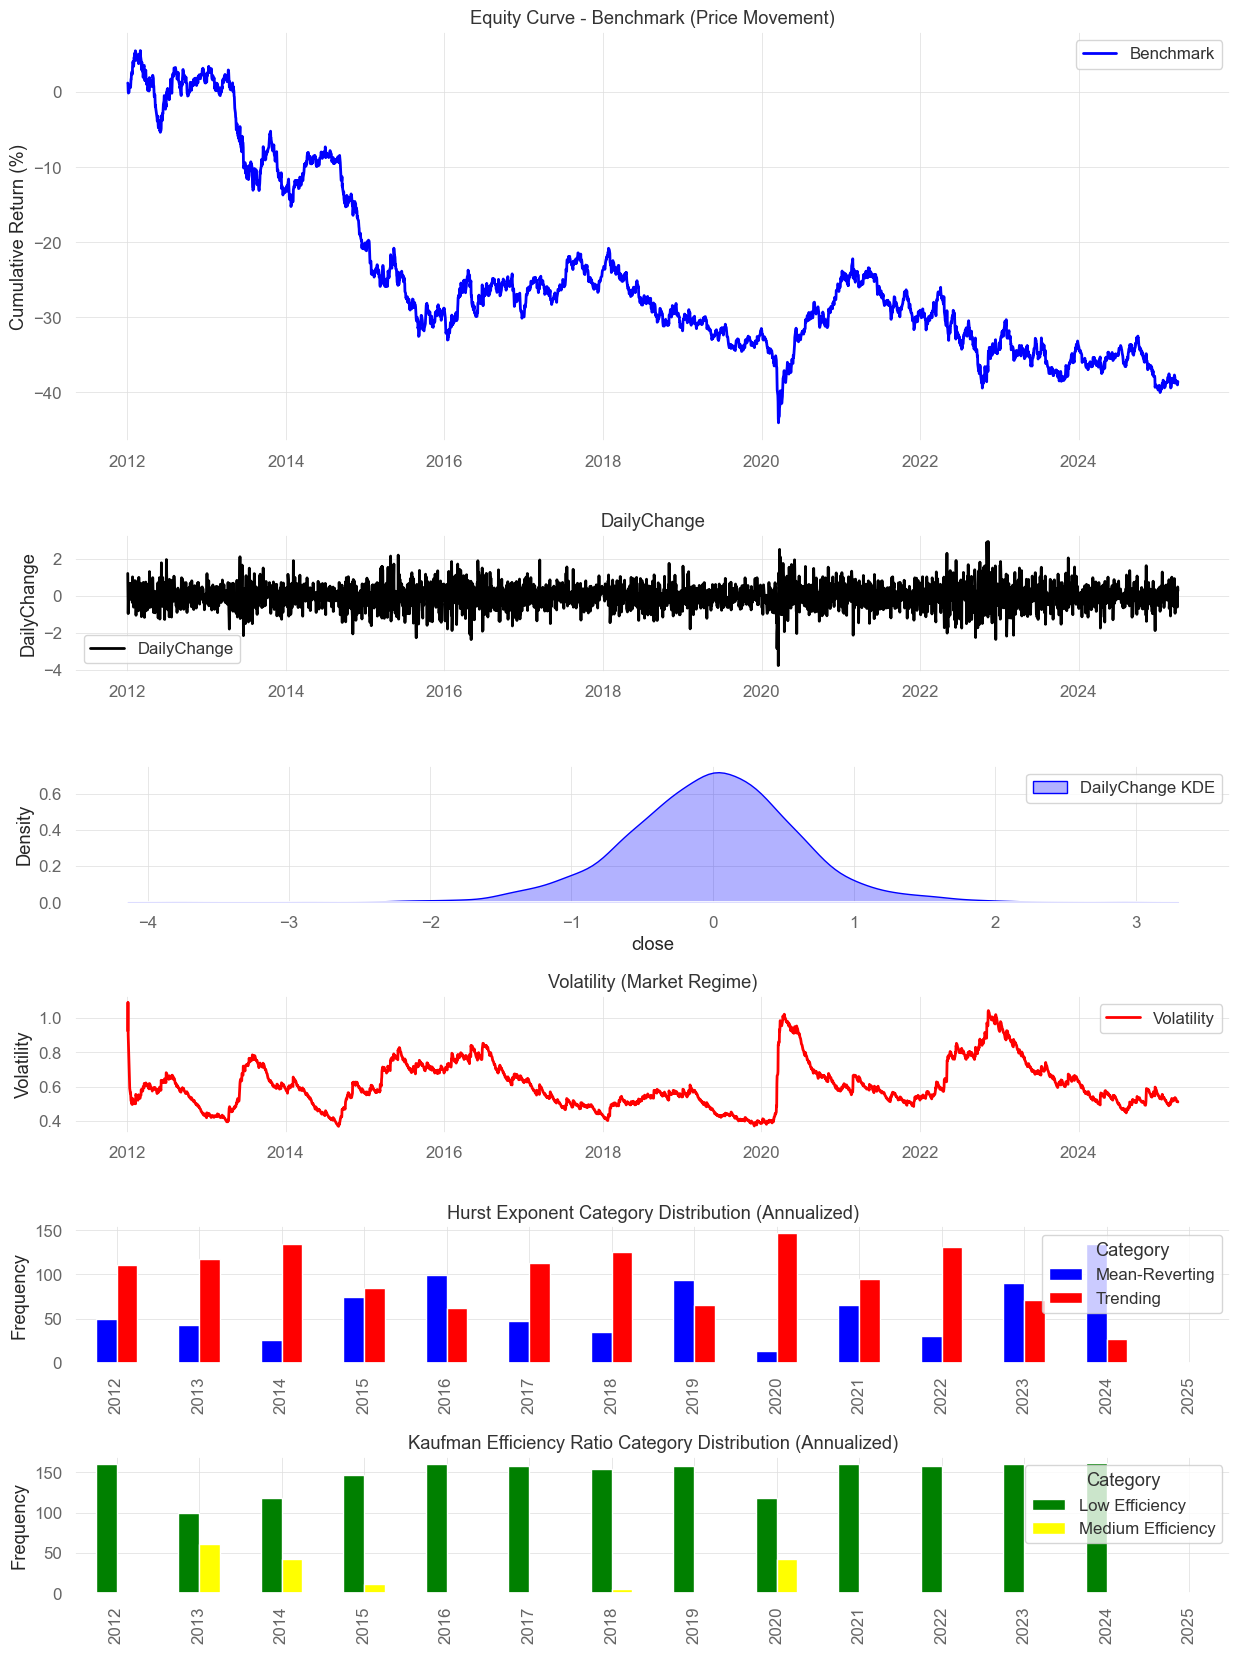

In [14]:
anz.Plot()

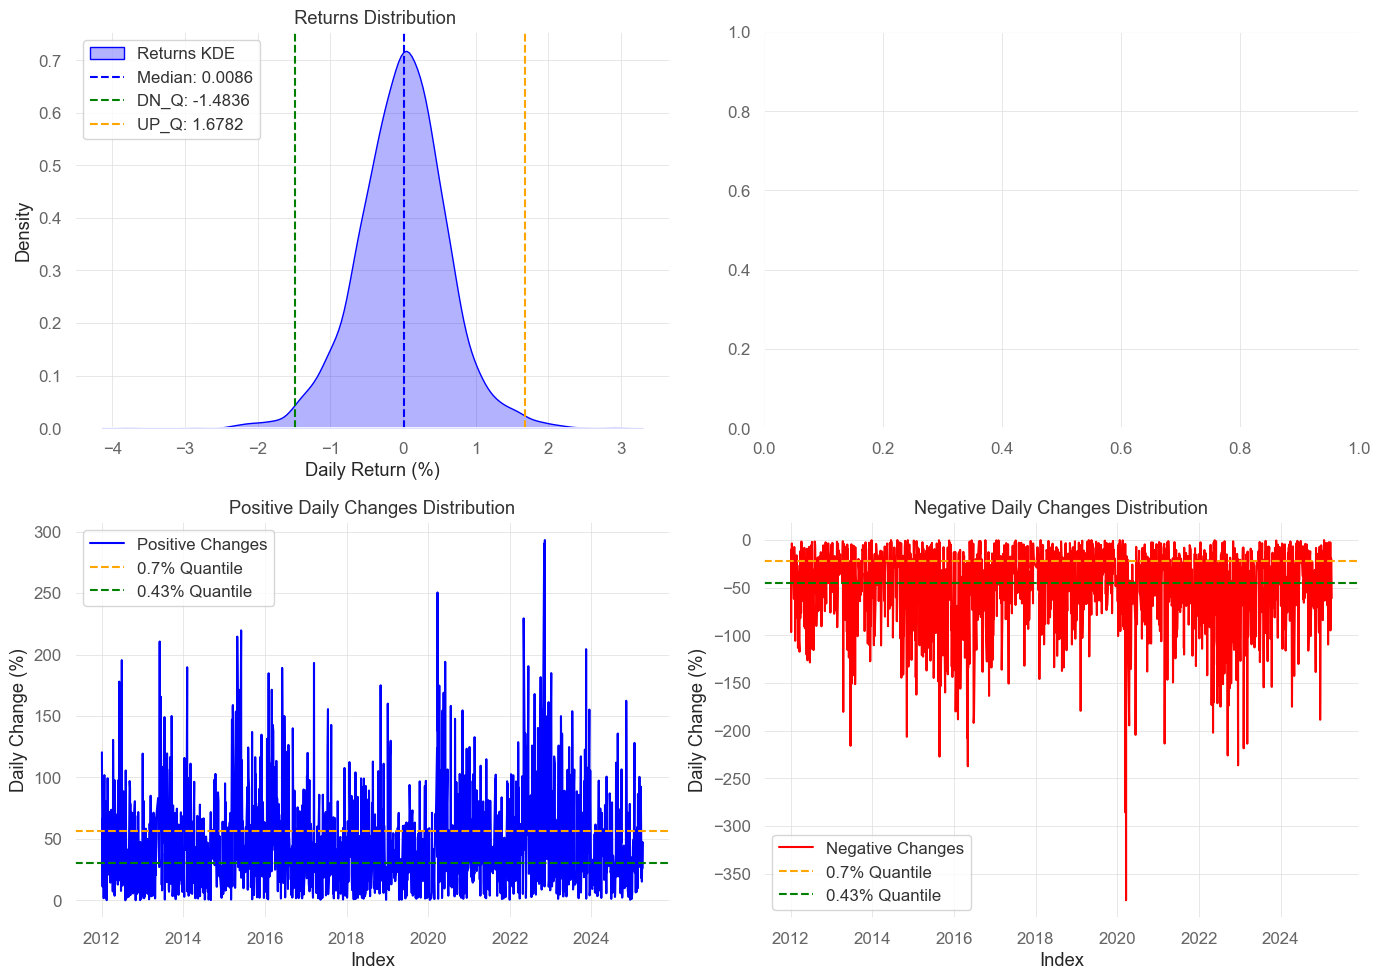

In [15]:
anz.Plot_DIST(**OptimalQ)

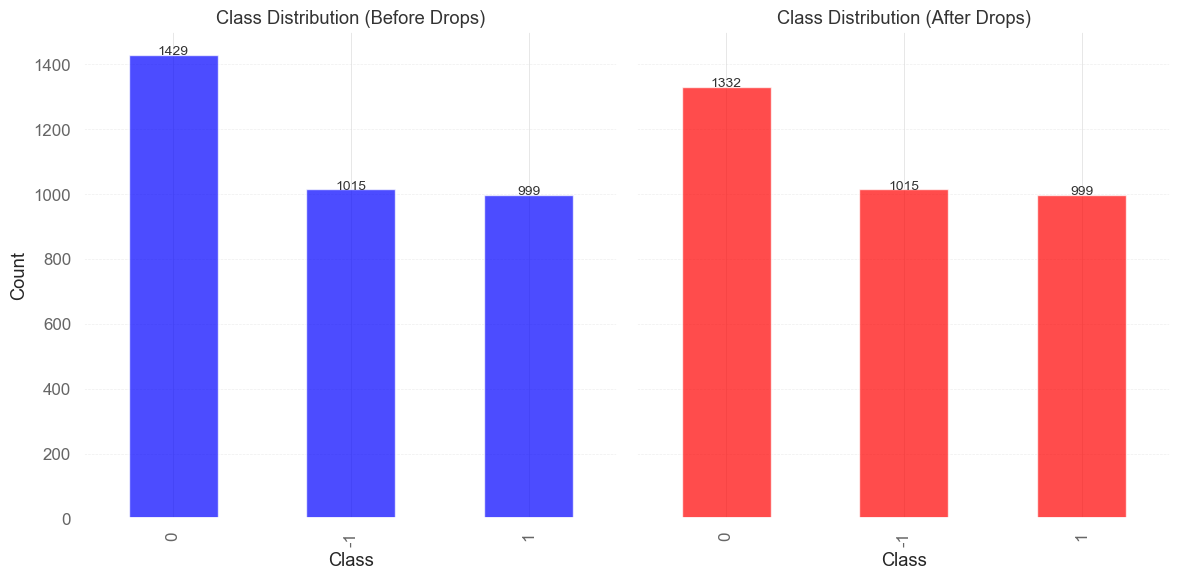

In [16]:
anz.plot_class_distribution_bar()

In [22]:
# ['sharpe' , 'CumRet' , 'RetMxdd' , 'p1' , 'f1' , 'ROC' , 'Accuracy'] , runner = ['timesplit' , 'Purgedkfold' , 'cpcv']

# setting default parameters for the base model for feature selection
estimator_params = {'n_estimators': 10 , 'max_depth' : 3 , 'sigma':0.10  , 'c':2 , 'transformer':np.sqrt}


# fetching the important features 
TopFeatures = bt.GetBestFeatures( None ,base_params =  estimator_params ,  runner = 'Purgedkfold' ,  threshold = 0.9)

100%|██████████████████████████████████████████████████████████████████████████████████| 29/29 [00:12<00:00,  2.38it/s]


100%|██████████████████████████████████████████████████████████████████████████████████| 29/29 [00:22<00:00,  1.31it/s]


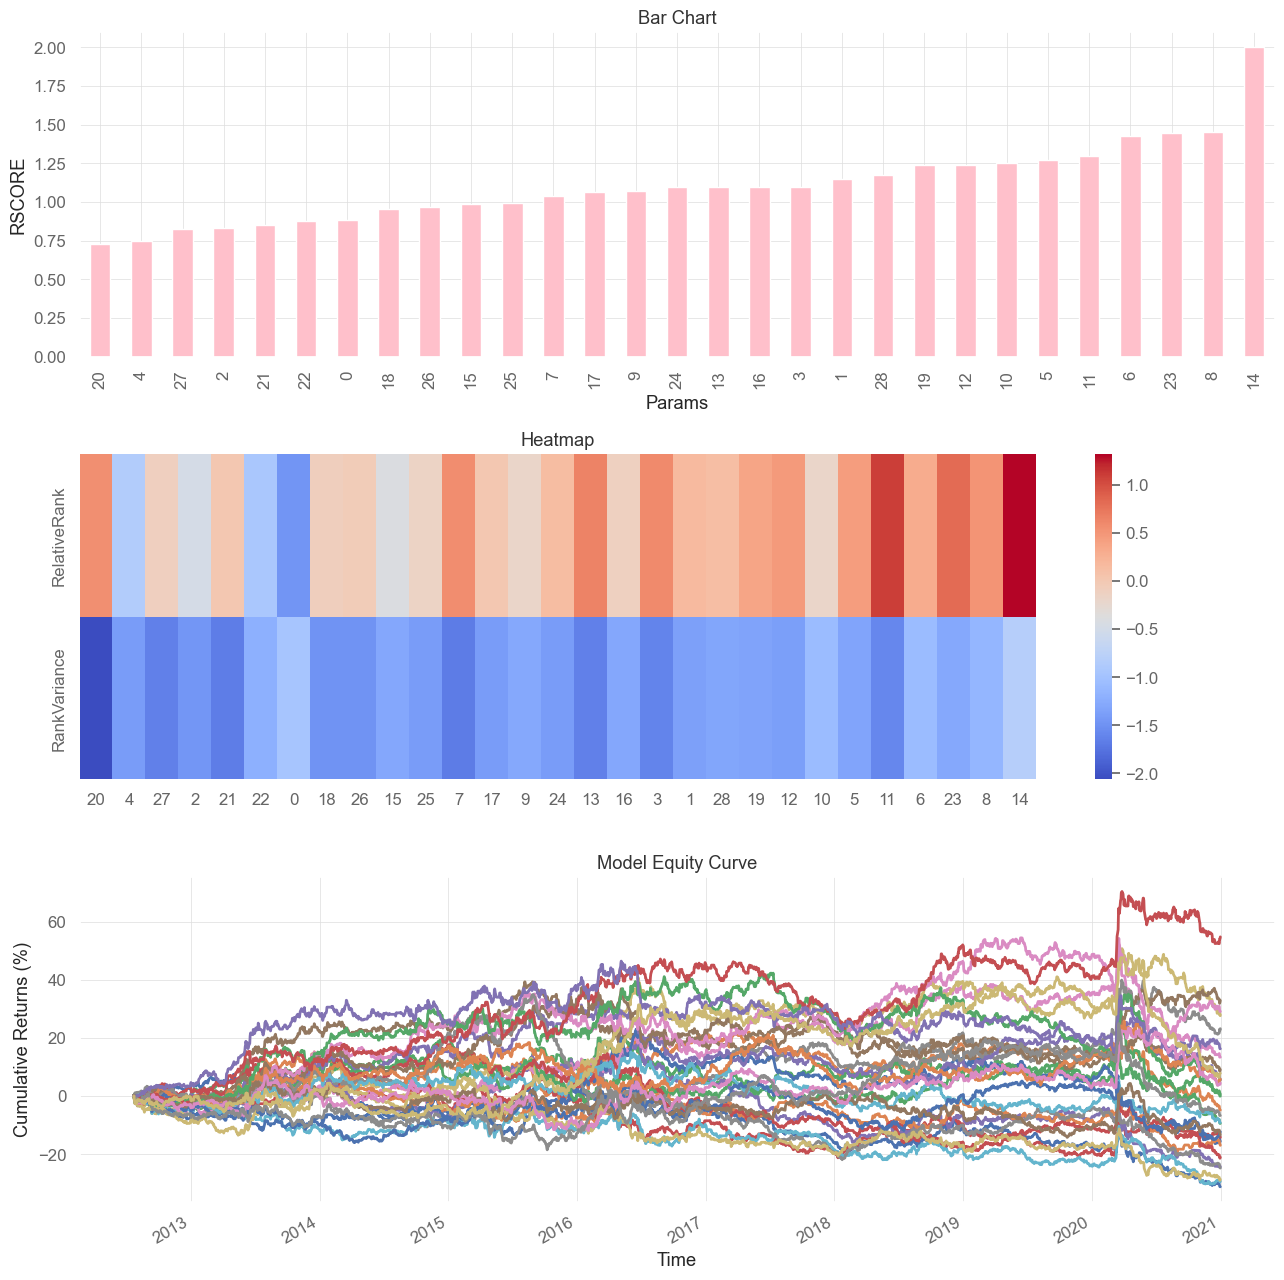

In [29]:
7# setting default parameters for training the base model
default_params =  {'n_estimators': 10 , 'max_depth' : 3  ,'sigma':0.10 , 'c':2 ,'transformer':np.sqrt}

# finding best params based on walkforward testing 
TopPerf = bt.RunRobust( TopFeatures , metrics = ['rolling_sharpe' , 'f1'] ,base_param =  default_params , runner = 'Purgedkfold' ,  IQR = (0.33 , 0.67))

In [30]:
outliers =  []
Model_ON_ACCOUNT = TopPerf + outliers
Model_ON_ACCOUNT 

[25, 7, 17, 9, 24, 13, 16, 3, 1]

In [31]:
Training_days =  2*252
Testing_days =    252
tuner.params_grid = {'n_estimators':(3 ,10) , 'max_depth':(1 , 3) ,  'sigma':(0 , 0.10) , 'min_samples_split':(2 , 20)}
tuner.default_params = {k :v for k , v in default_params.items() if k not in tuner.params_grid}
tuner.Integer = ['n_estimators' , 'max_depth' , 'n_splits' , 'min_samples_split']

# tuning the model based on combinatorial purged cross validation

best_params = tuner.Tuner(Model_ON_ACCOUNT , TopFeatures  , metrics = ['rolling_sharpe' , 'f1'] , runner = 'timesplit' ,
                          iteration =5, 
                          scoring = 'f1' , 
                          Shuffle_SEQ =[0  , 10 , 25 , 40 , 9] , training_days = Training_days , testing_days = Testing_days )

100%|████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:51<00:00,  5.77s/it]


In [32]:
ENSEM = tuner.GetCombinations_cluster(n_clusters  = 4)
ENSEM

  File "C:\Users\nwc\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\nwc\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\nwc\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\nwc\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


[(9, 25, 7, 17),
 (9, 13, 7, 17),
 (24, 25, 7, 17),
 (24, 13, 7, 17),
 (16, 25, 7, 17),
 (16, 13, 7, 17),
 (3, 25, 7, 17),
 (3, 13, 7, 17),
 (1, 25, 7, 17),
 (1, 13, 7, 17)]

In [33]:

# # getting best combinations
# BEST_PAIR , TRAIN_WIN , TEST_WIN  = rs.RunSimulation(ENSEM , TopFeatures , num_splits = 8  , n_samples  = 3 ,  metrics = ['rolling_sharpe'] , base_params = best_params , oos = False )

In [34]:
# # fetching best ensembles
# j = np.array([i for i in range(len(ENSEM))])
# best_ensembles = bt.GetBestEnsembles(ENSEM , j , TopFeatures ,base_params  = best_params , runner = 'Purgedkfold' , oos = True)

100%|████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:01<00:00,  6.10it/s]


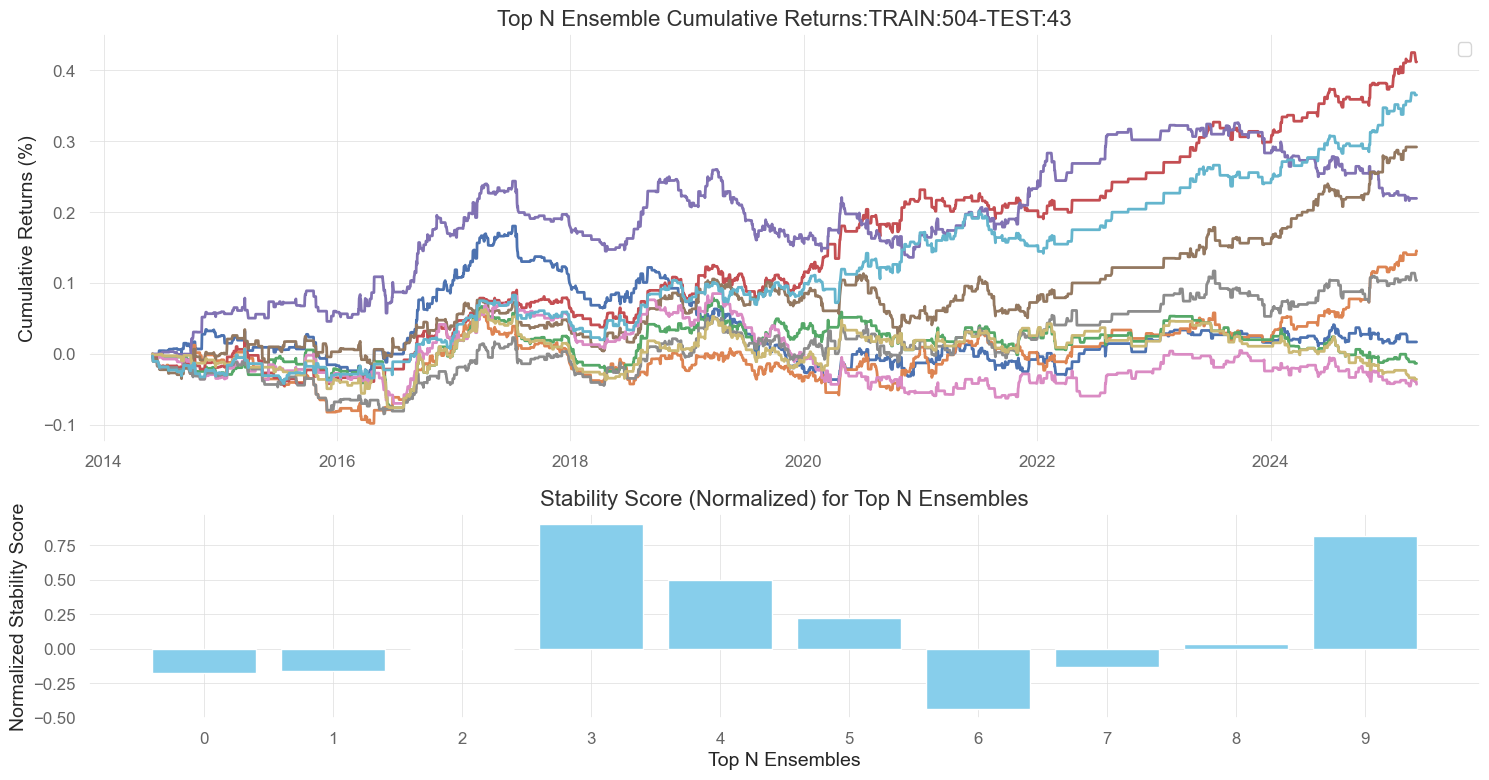

In [35]:
# fetching best ensembles
j = np.array([i for i in range(len(ENSEM))])

best_ensembles = bt.GetBestEnsembles(ENSEM , j , TopFeatures , base_params  = best_params  , 
                                     runner = 'timesplit' ,oos = True , 
                                     training_days = Training_days  , testing_days = Testing_days , anchored = False)

100%|█████████████████████████████████████████████████████| 10/10 [00:18<00:00,  1.88s/it]


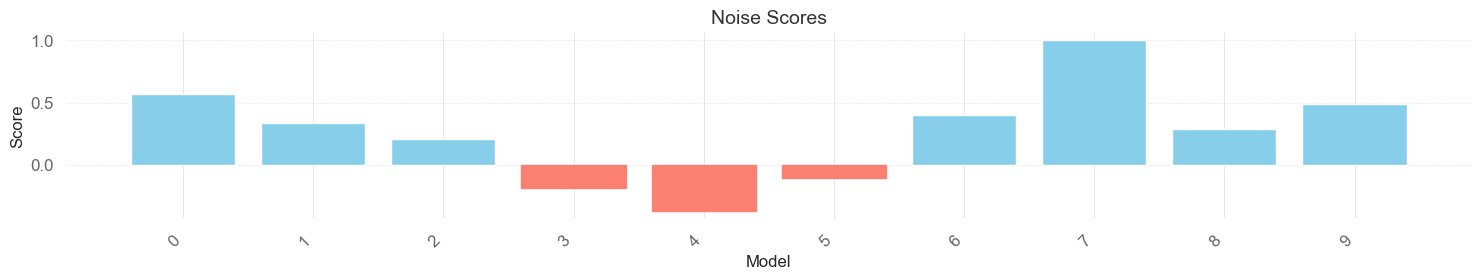

In [302]:
# noise test
j = np.array([i for i in range(len(ENSEM))])

w = ns.tester(ENSEM , j ,  TopFeatures , best_params , noise = [0.001 , 0.009] , 
                            sim_count = 20 ,runner = 'timesplit' ,oos = True , 
                            training_days = Training_days , testing_days = Testing_days  , anchored = False)

100%|█████████████████████████████████████████████████████| 10/10 [00:46<00:00,  4.66s/it]


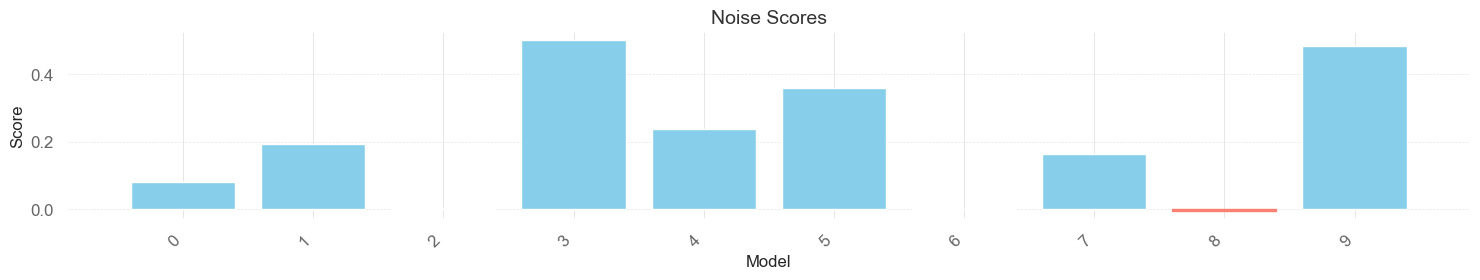

In [303]:
 pbt.tester(ENSEM , j , base_params = best_params , X_col = TopFeatures , runner ='timesplit' , oos = True , Shuffle_SEQ = np.arange(10) , 
            training_days = Training_days , testing_days = Testing_days , anchored = False )

In [49]:
idx  = 3
# ns.PlotEquities(idx)

In [308]:
# pbt.PlotEquities(idx)

Start date,2014-06-03
End date,2025-04-02
Total months,134
,Backtest
Annual return,3.137%
Cumulative returns,41.188%
Annual volatility,3.874%
Sharpe ratio,0.82
Calmar ratio,0.50
Stability,0.96
Max drawdown,-6.219%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,6.22,2015-03-19,2015-07-20,2016-09-09,387
1,4.80,2017-07-17,2018-04-03,2018-10-11,324
2,4.56,2019-03-27,2019-08-07,2020-01-24,218
3,3.34,2021-01-14,2022-01-20,2022-08-22,418
4,3.17,2020-07-20,2020-08-27,2020-11-03,77


Stress Events,mean,min,max
Oct14,-0.00%,-1.04%,0.74%
Fall2015,0.04%,-0.73%,1.21%
New Normal,0.01%,-1.73%,2.05%
Covid,0.02%,-1.76%,1.52%


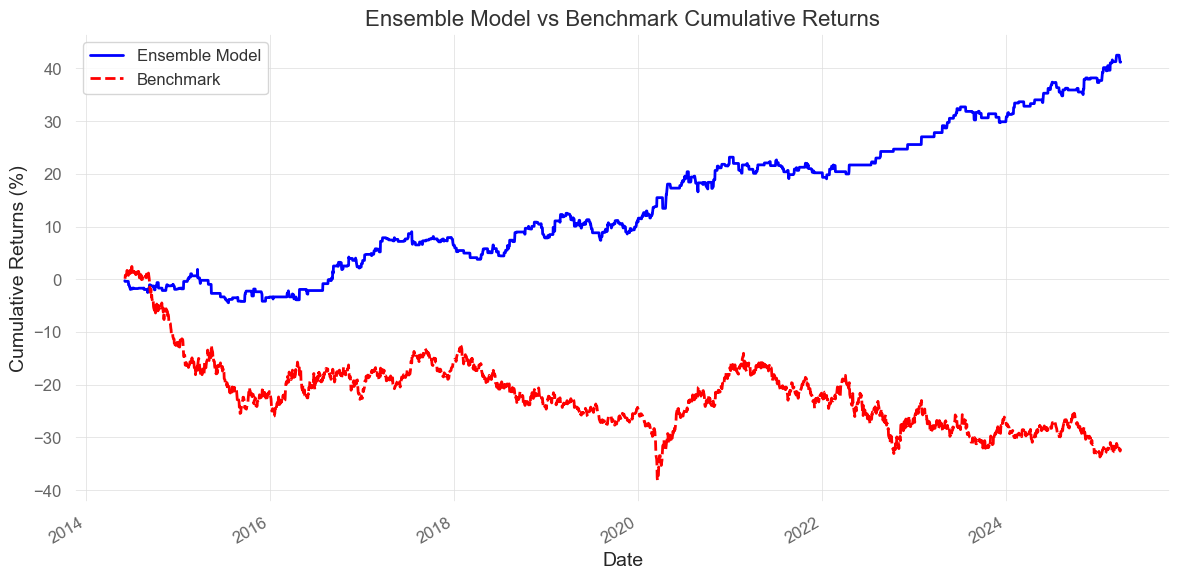

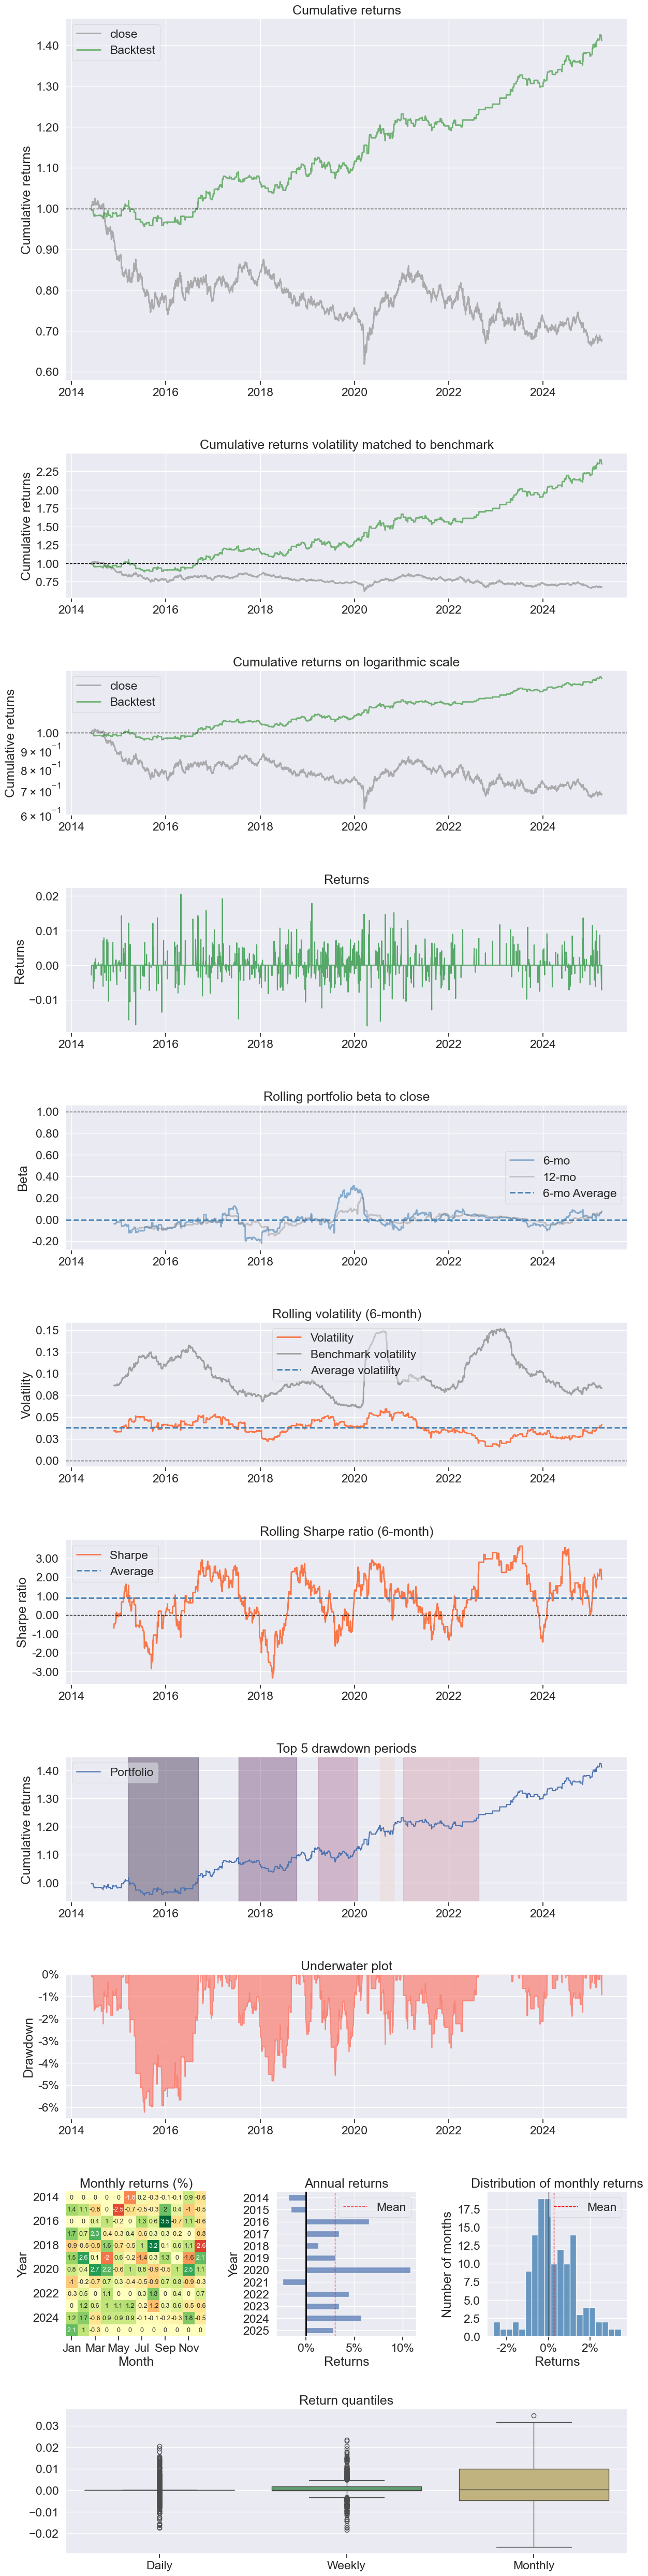

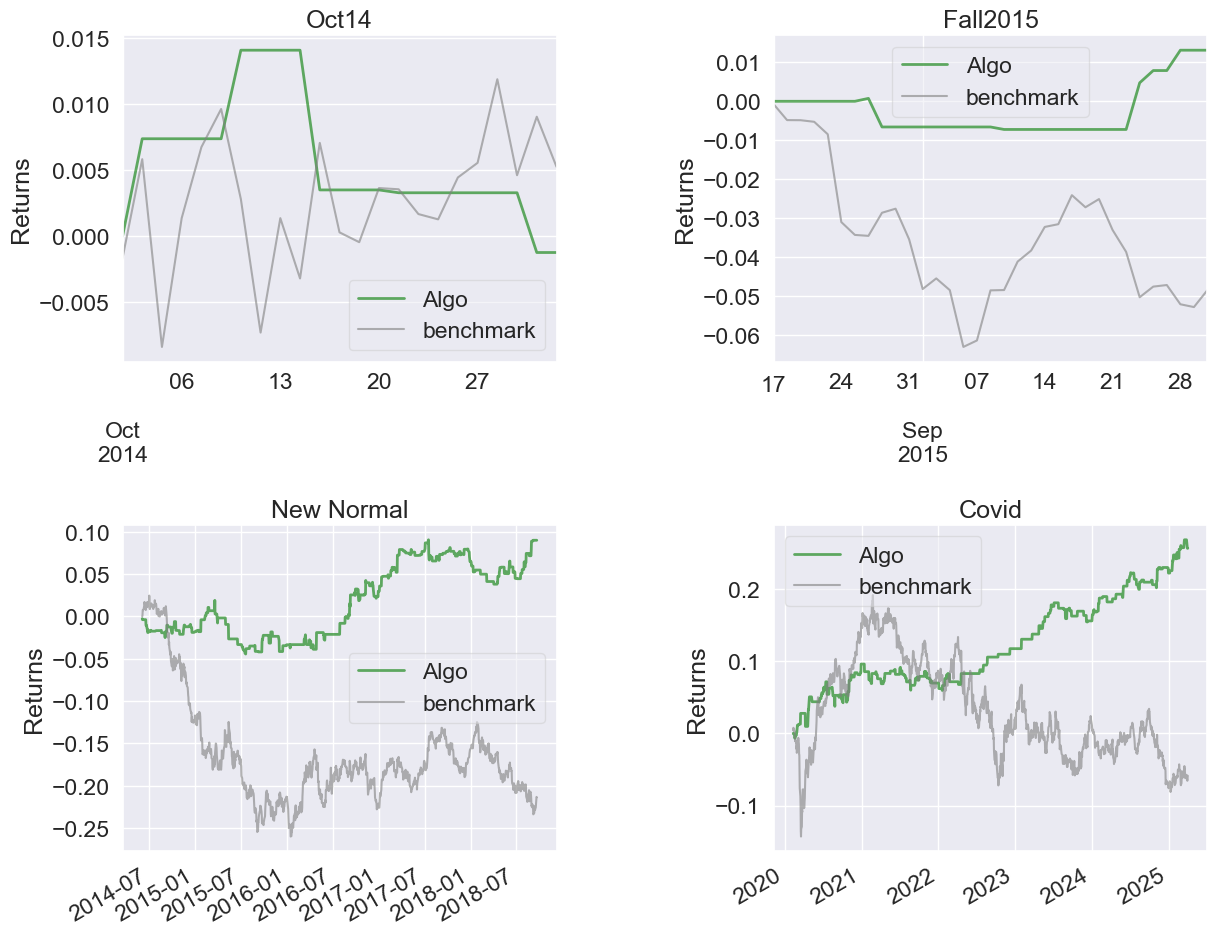

In [51]:
# ['full_split' , 'timesplit']
bt.GetEnsemblePerf( idx,  full_tear_sheet = True , save = True)

In [312]:
 for p in ENSEM[idx]:
    print('//////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////') 
    LINE_ = f'MODEL:{p}-:HYPERPARAMS:{best_params[p]}-:TopFeatures:{TopFeatures[p]}-:STRATEGY_PARAMS-:{par[p]}'
    print(LINE_)
     

//////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////
MODEL:24-:HYPERPARAMS:{'max_depth': 1, 'min_samples_split': 18, 'n_estimators': 4, 'sigma': 0.02989763774589579, 'c': 2, 'transformer': <ufunc 'sqrt'>}-:TopFeatures:['kurt_100', 'corr', 'daily_change_3', 'HurstRegime', 'rsi', 'Kuafman_ER_30', 'Kuafman_ER_100', 'z_slope_5', 'kurt_60', 'skew_30', 'daily_change_4', 'skew_10', 'daily_Range_1', 'daily_Range_5', 'daily_change', 'daily_Range_4', 'Kuafman_ER_60', 'daily_Range', 'z_slope_1', 'daily_Range_3', 'Volatility', 'daily_change_1', 'slope', 'kurt_30', 'daily_change_2', 'z_slope_4', 'skew_60']-:STRATEGY_PARAMS-:{'lookback': 12, 'normal_window': 19, 'window': 16}
//////////////////////////////////////////////////////////////////////////////////////////////////////////////////////////
MODEL:13-:HYPERPARAMS:{'max_depth': 2, 'min_samples_split': 9, 'n_estimators': 5, 'sigma': 0.0010581535878642968, 'c': 2, 'transformer':

In [165]:
# TRAIN_WIN = 1201

Updated From:2023-02-27 00:00:00+00:00 To:2025-01-31 00:00:00+00:00
TrainingWindow:504


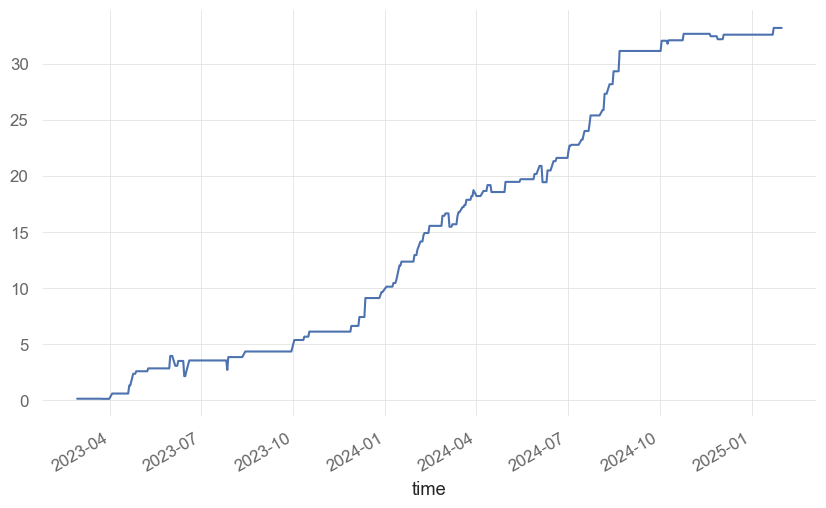

In [314]:
bt.TRAIN_SAVE_MODEL(ENSEM[idx] , TopFeatures , best_params , 'timesplit')